# A Benchmark of Text Embeddings and Clustering Algorithms for Scientific Topic Discovery
## Exploratory Data Analysis of the arXiv Scientific Paper Corpus

This notebook develops a presentation-quality exploratory data analysis (EDA) for a large arXiv-style scientific paper corpus. The analysis is designed to support downstream benchmarking of text embeddings, clustering algorithms, and category-based evaluation for scientific topic discovery.

**Notebook objectives**
- understand dataset structure, scale, and field completeness,
- quantify category imbalance and multi-label behavior,
- inspect title and abstract properties that matter for text representation,
- identify preprocessing choices that are sensible for embeddings and clustering,
- motivate an experimental split strategy, and
- surface risks, caveats, and report-ready recommendations.

**Project Context**

The downstream goal is not generic text classification; it is unsupervised or weakly supervised topic discovery over scientific papers. That makes several aspects of EDA especially important:

- label distributions matter because category labels will be used as external reference signals for evaluating clustering quality,
- text artifacts matter because scientific abstracts contain formulas, URLs, and cross-domain notation that interact differently with TF-IDF baselines versus transformer embeddings,
- time and domain skew matter because a benchmark can become dominated by recent, computer-science-heavy content if these shifts are not documented, and
- scale matters because some clustering algorithms that look reasonable on small corpora become impractical on a corpus with millions of documents.

To keep the notebook reproducible while respecting the dataset size, metadata-level analyses are computed from full-dataset cached summaries, while text-heavy analyses use a reproducible reservoir sample drawn from the full corpus.

## 1. Imports and Setup

The notebook expects a standard Python data-science stack. The first code cell checks for the required packages and installs any missing dependencies into the active kernel environment. If you prefer to install manually, run `pip install -r requirements.txt` before opening the notebook.

In [1]:
import importlib
import subprocess
import sys

import gzip
import hashlib
import json
import random
import re
import time
from array import array
from collections import Counter, defaultdict
from email.utils import parsedate_to_datetime
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "IPython": "ipython",
}

missing_packages = []
failed_imports = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except Exception:
        failed_imports.append(module_name)
        missing_packages.append(package_name)

if missing_packages:
    missing_packages = sorted(set(missing_packages))
    print(f"Active kernel Python: {sys.executable}")
    print("Installing missing packages for this kernel:", ", ".join(missing_packages))
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    except Exception as exc:
        raise RuntimeError(
            "Automatic dependency installation failed. Run `pip install -r requirements.txt` "
            "in the same environment as this notebook and rerun the first cells."
        ) from exc
    for module_name in REQUIRED_PACKAGES:
        importlib.import_module(module_name)
    print("Dependency installation complete.")
else:
    print(f"Active kernel Python: {sys.executable}")
    print("All required notebook packages are already installed.")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
pd.options.display.max_colwidth = 180
pd.options.display.float_format = lambda x: f"{x:,.3f}"

DATA_PATH = Path("arxiv-metadata-oai-snapshot.json")
ARTIFACT_DIR = Path("artifacts/eda")
RANDOM_SEED = 42
TEXT_ANALYSIS_SAMPLE = 20_000
SPLIT_SIMULATION_MIN_COUNT = 10

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH.resolve()}"

print(f"Dataset: {DATA_PATH.resolve()}")
print(f"Dataset size: {DATA_PATH.stat().st_size / 1024**3:,.2f} GB")

Active kernel Python: /Users/muneebhoda/Documents/Masters - Spring 2026/Semester One/Introduction to Data Mining/Project/.venv/bin/python
All required notebook packages are already installed.
Dataset: /Users/muneebhoda/Documents/Masters - Spring 2026/Semester One/Introduction to Data Mining/Project/arxiv-metadata-oai-snapshot.json
Dataset size: 4.77 GB


## 2. Utilities

The dataset is too large to load as a single in-memory dataframe without wasting memory. The helper functions below support a cache-first workflow:

- if full-dataset EDA artifacts already exist, the notebook reuses them immediately,
- if not, the notebook can build them from scratch in a single streaming pass over the JSONL file, and
- text-heavy analysis is based on a fixed reservoir sample so the notebook stays fast enough to rerun.

The full cache build is the only expensive step in this notebook. On first run it can take several minutes because it scans all 2.96 million records.

In [2]:
CATEGORY_RE = re.compile(r"^[A-Za-z\-]+(?:\.[A-Za-z\-]+)?$")
ID_RE = re.compile(r"^(?:[a-z\-]+(?:\.[A-Za-z\-]+)?/\d{7}|\d{4}\.\d{4,5})$")
WS_RE = re.compile(r"\s+")
NON_ALNUM_SPACE_RE = re.compile(r"[^a-z0-9\s]")
TOKEN_RE = re.compile(r"[A-Za-z0-9_+\-\.']+")


def normalize_ws(text: object) -> str:
    if text is None:
        return ""
    return WS_RE.sub(" ", str(text)).strip()


def split_categories(value: object) -> list[str]:
    text = normalize_ws(value)
    return text.split() if text else []


def get_domain(category: str) -> str:
    if not category:
        return "unknown"
    return category.split(".", 1)[0]


def reservoir_update(sample: list[dict], item: dict, sample_size: int, seen_count: int, rng: random.Random) -> None:
    if len(sample) < sample_size:
        sample.append(item)
        return
    j = rng.randrange(seen_count)
    if j < sample_size:
        sample[j] = item


def counter_to_frame(counter: Counter, key_name: str, value_name: str = "count") -> pd.DataFrame:
    frame = pd.DataFrame(counter.items(), columns=[key_name, value_name])
    if not frame.empty:
        frame = frame.sort_values(value_name, ascending=False).reset_index(drop=True)
    return frame


def percentile_summary(values) -> dict[str, float]:
    arr = np.asarray(values, dtype=np.float64)
    percentiles = [0, 25, 50, 75, 90, 95, 99, 100]
    return {str(p): float(np.percentile(arr, p)) for p in percentiles}


def clip_text(text: str, width: int = 220) -> str:
    text = normalize_ws(text)
    return text if len(text) <= width else text[: width - 3] + "..."


def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_jsonl_gz(path: Path) -> list[dict]:
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

In [3]:
def build_eda_artifacts(
    data_path: Path,
    artifact_dir: Path,
    seed: int = RANDOM_SEED,
    text_sample_size: int = 40_000,
    split_sample_size: int = 200_000,
    progress_every: int = 250_000,
) -> None:
    artifact_dir.mkdir(parents=True, exist_ok=True)

    rng_text = random.Random(seed)
    rng_split = random.Random(seed + 1)

    field_names = set()
    field_types = defaultdict(Counter)
    missing_counts = Counter()
    empty_string_counts = Counter()
    whitespace_only_counts = Counter()

    all_category_counts = Counter()
    primary_category_counts = Counter()
    primary_domain_counts = Counter()
    all_domain_counts = Counter()
    label_count_distribution = Counter()
    combo_counts = Counter()
    author_count_distribution = Counter()
    version_count_distribution = Counter()
    submission_year_counts = Counter()
    submission_month_counts = Counter()
    update_year_counts = Counter()
    update_lag_years = Counter()
    primary_category_year_counts = defaultdict(Counter)
    primary_domain_year_counts = defaultdict(Counter)
    malformed_category_token_counts = Counter()

    preview_rows = []
    text_sample = []
    split_sample = []

    suspect_id_count = 0
    invalid_submission_dates = 0
    invalid_update_dates = 0
    missing_primary_category = 0
    duplicate_paper_ids = 0
    duplicate_paper_id_examples = []
    seen_ids = set()

    exact_title_hashes = array("Q")
    normalized_title_hashes = array("Q")
    content_hashes = array("Q")
    title_char_lengths = array("I")
    title_word_lengths = array("I")
    abstract_char_lengths = array("I")
    abstract_word_lengths = array("I")
    author_counts_array = array("I")
    label_counts_array = array("I")
    version_counts_array = array("I")

    start = time.time()
    with data_path.open("r", encoding="utf-8") as f:
        for idx, line in enumerate(f, start=1):
            if not line.strip():
                continue

            record = json.loads(line)
            field_names.update(record.keys())

            if idx <= 5_000:
                for key, value in record.items():
                    field_types[key][type(value).__name__] += 1

            for key, value in record.items():
                if value is None:
                    missing_counts[key] += 1
                elif isinstance(value, str):
                    if value == "":
                        empty_string_counts[key] += 1
                    elif not value.strip():
                        whitespace_only_counts[key] += 1

            paper_id = normalize_ws(record.get("id"))
            if paper_id in seen_ids:
                duplicate_paper_ids += 1
                if len(duplicate_paper_id_examples) < 10:
                    duplicate_paper_id_examples.append(paper_id)
            else:
                seen_ids.add(paper_id)

            if paper_id and not ID_RE.match(paper_id):
                suspect_id_count += 1

            title = normalize_ws(record.get("title"))
            abstract = normalize_ws(record.get("abstract"))
            categories = split_categories(record.get("categories"))
            primary_category = categories[0] if categories else ""
            primary_domain = get_domain(primary_category) if primary_category else "unknown"

            authors_parsed = record.get("authors_parsed")
            author_count = len(authors_parsed) if isinstance(authors_parsed, list) else 0
            version_count = len(record.get("versions") or []) if isinstance(record.get("versions"), list) else 0

            title_char_lengths.append(len(title))
            title_word_lengths.append(len(title.split()))
            abstract_char_lengths.append(len(abstract))
            abstract_word_lengths.append(len(abstract.split()))
            author_counts_array.append(author_count)
            label_counts_array.append(len(categories))
            version_counts_array.append(version_count)

            author_count_distribution[author_count] += 1
            version_count_distribution[version_count] += 1

            exact_title_hash = int.from_bytes(
                hashlib.blake2b(title.encode("utf-8"), digest_size=8).digest(),
                "big",
            ) if title else 0
            normalized_title = normalize_ws(NON_ALNUM_SPACE_RE.sub(" ", title.lower())) if title else ""
            normalized_title_hash = int.from_bytes(
                hashlib.blake2b(normalized_title.encode("utf-8"), digest_size=8).digest(),
                "big",
            ) if normalized_title else 0
            content_text = f"{normalized_title}\n{abstract.lower()}"
            content_hash = int.from_bytes(
                hashlib.blake2b(content_text.encode("utf-8"), digest_size=8).digest(),
                "big",
            ) if content_text.strip() else 0

            exact_title_hashes.append(exact_title_hash)
            normalized_title_hashes.append(normalized_title_hash)
            content_hashes.append(content_hash)

            if categories:
                all_category_counts.update(categories)
                primary_category_counts[primary_category] += 1
                primary_domain_counts[primary_domain] += 1
                all_domain_counts.update(get_domain(cat) for cat in categories)
                label_count_distribution[len(categories)] += 1
                if len(categories) > 1:
                    combo_counts[" | ".join(categories)] += 1
                malformed_category_token_counts.update(
                    cat for cat in categories if not CATEGORY_RE.match(cat)
                )
            else:
                missing_primary_category += 1

            versions = record.get("versions")
            submission_year = None
            if isinstance(versions, list) and versions:
                created = versions[0].get("created")
                try:
                    submitted_at = parsedate_to_datetime(created)
                    submission_year = submitted_at.year
                    submission_year_counts[submission_year] += 1
                    submission_month_counts[f"{submitted_at.year:04d}-{submitted_at.month:02d}"] += 1
                except Exception:
                    invalid_submission_dates += 1
            else:
                invalid_submission_dates += 1

            update_date = normalize_ws(record.get("update_date"))
            update_year = None
            if update_date:
                try:
                    update_year = int(update_date[:4])
                    update_year_counts[update_year] += 1
                except Exception:
                    invalid_update_dates += 1
            else:
                invalid_update_dates += 1

            if submission_year is not None and update_year is not None:
                update_lag_years[max(update_year - submission_year, 0)] += 1
                if primary_category:
                    primary_category_year_counts[primary_category][submission_year] += 1
                    primary_domain_year_counts[primary_domain][submission_year] += 1

            sample_row = {
                "id": paper_id,
                "title": title,
                "abstract": abstract,
                "categories": " ".join(categories),
                "primary_category": primary_category,
                "primary_domain": primary_domain,
                "submission_year": submission_year,
                "update_year": update_year,
                "author_count": author_count,
                "label_count": len(categories),
                "title_char_len": len(title),
                "title_word_len": len(title.split()),
                "abstract_char_len": len(abstract),
                "abstract_word_len": len(abstract.split()),
                "version_count": version_count,
            }

            if len(preview_rows) < 5:
                preview_rows.append(
                    {
                        "id": paper_id,
                        "title": title,
                        "categories": " ".join(categories),
                        "update_date": update_date,
                        "authors": normalize_ws(record.get("authors")),
                        "abstract": clip_text(abstract, width=400),
                    }
                )

            reservoir_update(text_sample, sample_row, text_sample_size, idx, rng_text)
            reservoir_update(
                split_sample,
                {
                    "id": paper_id,
                    "primary_category": primary_category,
                    "primary_domain": primary_domain,
                },
                split_sample_size,
                idx,
                rng_split,
            )

            if idx % progress_every == 0:
                elapsed = time.time() - start
                print(f"Processed {idx:,} records in {elapsed / 60:.1f} minutes")

    record_count = idx
    print(f"Finished full pass over {record_count:,} records.")

    np.savez_compressed(
        artifact_dir / "length_arrays.npz",
        title_char_len=np.array(title_char_lengths, dtype=np.uint32),
        title_word_len=np.array(title_word_lengths, dtype=np.uint32),
        abstract_char_len=np.array(abstract_char_lengths, dtype=np.uint32),
        abstract_word_len=np.array(abstract_word_lengths, dtype=np.uint32),
        author_count=np.array(author_counts_array, dtype=np.uint16),
        label_count=np.array(label_counts_array, dtype=np.uint8),
        version_count=np.array(version_counts_array, dtype=np.uint8),
    )

    column_rows = []
    for field in sorted(field_names):
        type_counter = field_types.get(field, Counter())
        inferred_dtype = type_counter.most_common(1)[0][0] if type_counter else "unknown"
        column_rows.append(
            {
                "column": field,
                "inferred_dtype_sample": inferred_dtype,
                "missing_count": int(missing_counts.get(field, 0)),
                "missing_pct": float(missing_counts.get(field, 0) / record_count * 100),
                "empty_string_count": int(empty_string_counts.get(field, 0)),
                "whitespace_only_count": int(whitespace_only_counts.get(field, 0)),
            }
        )
    pd.DataFrame(column_rows).to_csv(artifact_dir / "column_overview.csv", index=False)

    all_category_df = counter_to_frame(all_category_counts, "category")
    all_category_df["share_pct"] = all_category_df["count"] / record_count * 100
    all_category_df.to_csv(artifact_dir / "all_category_counts.csv", index=False)

    primary_category_df = counter_to_frame(primary_category_counts, "primary_category")
    primary_category_df["share_pct"] = primary_category_df["count"] / record_count * 100
    primary_category_df.to_csv(artifact_dir / "primary_category_counts.csv", index=False)

    primary_domain_df = counter_to_frame(primary_domain_counts, "primary_domain")
    primary_domain_df["share_pct"] = primary_domain_df["count"] / record_count * 100
    primary_domain_df.to_csv(artifact_dir / "primary_domain_counts.csv", index=False)

    all_domain_df = counter_to_frame(all_domain_counts, "domain")
    all_domain_df["share_pct"] = all_domain_df["count"] / all_domain_df["count"].sum() * 100
    all_domain_df.to_csv(artifact_dir / "all_domain_counts.csv", index=False)

    label_count_df = counter_to_frame(label_count_distribution, "label_count")
    label_count_df["share_pct"] = label_count_df["count"] / record_count * 100
    label_count_df = label_count_df.sort_values("label_count").reset_index(drop=True)
    label_count_df.to_csv(artifact_dir / "label_count_distribution.csv", index=False)

    combo_df = counter_to_frame(combo_counts, "category_combination").head(200)
    combo_df["share_pct"] = combo_df["count"] / record_count * 100
    combo_df.to_csv(artifact_dir / "category_combination_counts_top200.csv", index=False)

    submission_year_df = counter_to_frame(submission_year_counts, "submission_year")
    submission_year_df = submission_year_df.sort_values("submission_year").reset_index(drop=True)
    submission_year_df.to_csv(artifact_dir / "submission_year_counts.csv", index=False)

    submission_month_df = counter_to_frame(submission_month_counts, "submission_month")
    submission_month_df = submission_month_df.sort_values("submission_month").reset_index(drop=True)
    submission_month_df.to_csv(artifact_dir / "submission_month_counts.csv", index=False)

    primary_category_year_rows = []
    for category, year_counts in primary_category_year_counts.items():
        for year, count in year_counts.items():
            primary_category_year_rows.append(
                {"primary_category": category, "submission_year": year, "count": count}
            )
    pd.DataFrame(primary_category_year_rows).to_csv(
        artifact_dir / "primary_category_year_counts.csv",
        index=False,
    )

    primary_domain_year_rows = []
    for domain, year_counts in primary_domain_year_counts.items():
        for year, count in year_counts.items():
            primary_domain_year_rows.append(
                {"primary_domain": domain, "submission_year": year, "count": count}
            )
    pd.DataFrame(primary_domain_year_rows).to_csv(
        artifact_dir / "primary_domain_year_counts.csv",
        index=False,
    )

    counter_to_frame(author_count_distribution, "author_count").sort_values("author_count").to_csv(
        artifact_dir / "author_count_distribution.csv",
        index=False,
    )
    counter_to_frame(version_count_distribution, "version_count").sort_values("version_count").to_csv(
        artifact_dir / "version_count_distribution.csv",
        index=False,
    )
    counter_to_frame(update_year_counts, "update_year").sort_values("update_year").to_csv(
        artifact_dir / "update_year_counts.csv",
        index=False,
    )
    counter_to_frame(update_lag_years, "update_lag_years").sort_values("update_lag_years").to_csv(
        artifact_dir / "update_lag_year_distribution.csv",
        index=False,
    )
    counter_to_frame(malformed_category_token_counts, "malformed_category").to_csv(
        artifact_dir / "malformed_category_tokens.csv",
        index=False,
    )

    with gzip.open(artifact_dir / "text_sample.jsonl.gz", "wt", encoding="utf-8") as f:
        for row in text_sample:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

    pd.DataFrame(split_sample).to_csv(artifact_dir / "split_sample.csv", index=False)
    with (artifact_dir / "preview_rows.json").open("w", encoding="utf-8") as f:
        json.dump(preview_rows, f, ensure_ascii=False, indent=2)

    def summarize_hash_duplicates(hash_values: array) -> dict:
        arr = np.asarray(hash_values, dtype=np.uint64)
        unique_hashes, counts = np.unique(arr, return_counts=True)
        duplicate_mask = counts > 1
        top = []
        if duplicate_mask.any():
            dup_hashes = unique_hashes[duplicate_mask]
            dup_counts = counts[duplicate_mask]
            order = np.argsort(dup_counts)[::-1][:20]
            top = [{"hash": int(dup_hashes[i]), "count": int(dup_counts[i])} for i in order]
        return {
            "duplicated_unique_values": int(duplicate_mask.sum()),
            "duplicate_records": int((counts[duplicate_mask] - 1).sum()),
            "top_hashes": top,
        }

    duplicate_summary = {
        "exact_title": summarize_hash_duplicates(exact_title_hashes),
        "normalized_title": summarize_hash_duplicates(normalized_title_hashes),
        "title_abstract_content": summarize_hash_duplicates(content_hashes),
    }

    top_hash_lookup = {
        "exact_title": {item["hash"] for item in duplicate_summary["exact_title"]["top_hashes"]},
        "normalized_title": {item["hash"] for item in duplicate_summary["normalized_title"]["top_hashes"]},
        "title_abstract_content": {item["hash"] for item in duplicate_summary["title_abstract_content"]["top_hashes"]},
    }

    duplicate_examples = {
        "exact_title": {},
        "normalized_title": {},
        "title_abstract_content": {},
    }
    with data_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            record = json.loads(line)
            title = normalize_ws(record.get("title"))
            abstract = normalize_ws(record.get("abstract"))
            categories = " ".join(split_categories(record.get("categories")))
            example = {
                "id": normalize_ws(record.get("id")),
                "title": title,
                "categories": categories,
                "abstract_preview": clip_text(abstract, width=300),
            }
            exact_hash = int.from_bytes(
                hashlib.blake2b(title.encode("utf-8"), digest_size=8).digest(),
                "big",
            ) if title else 0
            normalized_title = normalize_ws(NON_ALNUM_SPACE_RE.sub(" ", title.lower())) if title else ""
            norm_hash = int.from_bytes(
                hashlib.blake2b(normalized_title.encode("utf-8"), digest_size=8).digest(),
                "big",
            ) if normalized_title else 0
            content_text = f"{normalized_title}\n{abstract.lower()}"
            content_hash = int.from_bytes(
                hashlib.blake2b(content_text.encode("utf-8"), digest_size=8).digest(),
                "big",
            ) if content_text.strip() else 0

            if exact_hash in top_hash_lookup["exact_title"] and str(exact_hash) not in duplicate_examples["exact_title"]:
                duplicate_examples["exact_title"][str(exact_hash)] = example
            if norm_hash in top_hash_lookup["normalized_title"] and str(norm_hash) not in duplicate_examples["normalized_title"]:
                duplicate_examples["normalized_title"][str(norm_hash)] = example
            if content_hash in top_hash_lookup["title_abstract_content"] and str(content_hash) not in duplicate_examples["title_abstract_content"]:
                duplicate_examples["title_abstract_content"][str(content_hash)] = example

    summary = {
        "data_path": str(data_path),
        "record_count": int(record_count),
        "field_names": sorted(field_names),
        "preview_row_count": len(preview_rows),
        "unique_all_categories": int(len(all_category_counts)),
        "unique_primary_categories": int(len(primary_category_counts)),
        "unique_primary_domains": int(len(primary_domain_counts)),
        "suspect_id_count": int(suspect_id_count),
        "invalid_submission_dates": int(invalid_submission_dates),
        "invalid_update_dates": int(invalid_update_dates),
        "missing_primary_category": int(missing_primary_category),
        "duplicate_paper_ids": int(duplicate_paper_ids),
        "duplicate_paper_id_examples": duplicate_paper_id_examples,
        "missing_counts": {k: int(v) for k, v in missing_counts.items()},
        "empty_string_counts": {k: int(v) for k, v in empty_string_counts.items()},
        "whitespace_only_counts": {k: int(v) for k, v in whitespace_only_counts.items()},
        "top_primary_category_share_pct": float(primary_category_df.iloc[0]["share_pct"]) if not primary_category_df.empty else 0.0,
        "top_primary_domain_share_pct": float(primary_domain_df.iloc[0]["share_pct"]) if not primary_domain_df.empty else 0.0,
        "single_label_share_pct": float(label_count_df.loc[label_count_df["label_count"] == 1, "share_pct"].iloc[0]) if (label_count_df["label_count"] == 1).any() else 0.0,
        "multi_label_share_pct": float(label_count_df.loc[label_count_df["label_count"] > 1, "share_pct"].sum()) if not label_count_df.empty else 0.0,
        "rare_primary_categories_le_10": int((primary_category_df["count"] <= 10).sum()) if not primary_category_df.empty else 0,
        "rare_primary_categories_le_50": int((primary_category_df["count"] <= 50).sum()) if not primary_category_df.empty else 0,
        "length_percentiles": {
            "title_char_len": percentile_summary(title_char_lengths),
            "title_word_len": percentile_summary(title_word_lengths),
            "abstract_char_len": percentile_summary(abstract_char_lengths),
            "abstract_word_len": percentile_summary(abstract_word_lengths),
            "author_count": percentile_summary(author_counts_array),
            "label_count": percentile_summary(label_counts_array),
            "version_count": percentile_summary(version_counts_array),
        },
        "duplicate_summary": duplicate_summary,
    }

    with (artifact_dir / "duplicate_examples.json").open("w", encoding="utf-8") as f:
        json.dump(duplicate_examples, f, ensure_ascii=False, indent=2)
    with (artifact_dir / "summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)


def ensure_eda_artifacts(data_path: Path, artifact_dir: Path, refresh: bool = False) -> None:
    required = [
        artifact_dir / "summary.json",
        artifact_dir / "column_overview.csv",
        artifact_dir / "primary_category_counts.csv",
        artifact_dir / "primary_domain_counts.csv",
        artifact_dir / "submission_year_counts.csv",
        artifact_dir / "length_arrays.npz",
        artifact_dir / "text_sample.jsonl.gz",
        artifact_dir / "split_sample.csv",
    ]
    if refresh or not all(path.exists() for path in required):
        print("Building EDA artifacts from the raw JSONL dataset. This may take several minutes.")
        build_eda_artifacts(data_path, artifact_dir)
    else:
        print(f"Using cached EDA artifacts from {artifact_dir.resolve()}")

In [4]:
ensure_eda_artifacts(DATA_PATH, ARTIFACT_DIR, refresh=False)

summary = load_json(ARTIFACT_DIR / "summary.json")
duplicate_examples = load_json(ARTIFACT_DIR / "duplicate_examples.json")
preview_df = pd.DataFrame(load_json(ARTIFACT_DIR / "preview_rows.json"))

column_overview = pd.read_csv(ARTIFACT_DIR / "column_overview.csv")
all_category_counts = pd.read_csv(ARTIFACT_DIR / "all_category_counts.csv")
primary_category_counts = pd.read_csv(ARTIFACT_DIR / "primary_category_counts.csv")
primary_domain_counts = pd.read_csv(ARTIFACT_DIR / "primary_domain_counts.csv")
all_domain_counts = pd.read_csv(ARTIFACT_DIR / "all_domain_counts.csv")
label_count_distribution = pd.read_csv(ARTIFACT_DIR / "label_count_distribution.csv")
category_combinations = pd.read_csv(ARTIFACT_DIR / "category_combination_counts_top200.csv")
submission_year_counts = pd.read_csv(ARTIFACT_DIR / "submission_year_counts.csv")
submission_month_counts = pd.read_csv(ARTIFACT_DIR / "submission_month_counts.csv")
primary_domain_year_counts = pd.read_csv(ARTIFACT_DIR / "primary_domain_year_counts.csv")
author_count_distribution = pd.read_csv(ARTIFACT_DIR / "author_count_distribution.csv")
update_lag_distribution = pd.read_csv(ARTIFACT_DIR / "update_lag_year_distribution.csv")
malformed_category_tokens = pd.read_csv(ARTIFACT_DIR / "malformed_category_tokens.csv")
split_sample_df = pd.read_csv(ARTIFACT_DIR / "split_sample.csv")
text_sample_df = pd.DataFrame(load_jsonl_gz(ARTIFACT_DIR / "text_sample.jsonl.gz"))
length_arrays = np.load(ARTIFACT_DIR / "length_arrays.npz")

title_char_len = length_arrays["title_char_len"]
title_word_len = length_arrays["title_word_len"]
abstract_char_len = length_arrays["abstract_char_len"]
abstract_word_len = length_arrays["abstract_word_len"]
author_count_arr = length_arrays["author_count"]
label_count_arr = length_arrays["label_count"]
version_count_arr = length_arrays["version_count"]

print(f"Loaded cached summaries for {summary['record_count']:,} papers.")
print(f"Text sample size: {len(text_sample_df):,}")
print(f"Split simulation sample size: {len(split_sample_df):,}")

Using cached EDA artifacts from /Users/muneebhoda/Documents/Masters - Spring 2026/Semester One/Introduction to Data Mining/Project/artifacts/eda


Loaded cached summaries for 2,963,163 papers.
Text sample size: 40,000
Split simulation sample size: 200,000


## 3. Data Loading

The raw corpus is stored as a large JSONL file. Rather than loading the full file into a dataframe, this notebook works from cached full-dataset summaries and a reproducible reservoir sample for text-intensive analyses. This keeps the notebook memory-conscious without sacrificing coverage on the metadata-level analyses that matter most for the benchmark.

## 4. Dataset Overview

In [5]:
overview_metrics = pd.DataFrame(
    [
        ("Total records", f"{summary['record_count']:,}"),
        ("Unique primary categories", f"{summary['unique_primary_categories']:,}"),
        ("Unique categories across all labels", f"{summary['unique_all_categories']:,}"),
        ("Unique primary domains", f"{summary['unique_primary_domains']:,}"),
        ("Date coverage", f"{submission_year_counts['submission_year'].min()} to {submission_year_counts['submission_year'].max()}"),
        ("Dataset file size", f"{DATA_PATH.stat().st_size / 1024**3:,.2f} GB"),
        ("Text analysis sample", f"{len(text_sample_df):,} papers"),
        ("Split simulation sample", f"{len(split_sample_df):,} papers"),
    ],
    columns=["Metric", "Value"],
)

column_roles = pd.DataFrame(
    [
        ("id", "Unique paper identifier used for deduplication and joins", "High"),
        ("title", "Short scientific summary; useful for lightweight retrieval and combined text representations", "High"),
        ("abstract", "Main textual field for embeddings and clustering", "High"),
        ("categories", "Multi-label arXiv subject assignments; first token is the primary label", "High"),
        ("authors", "Raw author string; useful mainly for descriptive metadata", "Medium"),
        ("authors_parsed", "Structured author list; enables author-count analysis", "Medium"),
        ("versions", "Version history; first entry provides an effective submission date", "High"),
        ("update_date", "Latest update date; useful for temporal skew and revision lag", "High"),
        ("comments", "Optional free-text notes; potentially noisy", "Low"),
        ("journal-ref", "Optional publication metadata; incomplete", "Low"),
        ("doi", "Optional publication identifier; incomplete", "Low"),
        ("report-no", "Optional report number; extremely sparse", "Low"),
        ("license", "Usage license metadata; informative but not central for clustering", "Low"),
        ("submitter", "Submission contact; not central for topic discovery", "Low"),
    ],
    columns=["Column", "Interpretation", "Project relevance"],
)

display(overview_metrics)
display(column_overview.sort_values("column").reset_index(drop=True))
display(column_roles)
display(preview_df)

,Metric,Value
0,Total records,"2,963,163"
1,Unique primary categories,172
2,Unique categories across all labels,176
3,Unique primary domains,38
4,Date coverage,1986 to 2026
5,Dataset file size,4.77 GB
6,Text analysis sample,"40,000 papers"
7,Split simulation sample,"200,000 papers"


,column,inferred_dtype_sample,missing_count,missing_pct,empty_string_count,whitespace_only_count
0,abstract,str,0,0.000,0,0
1,authors,str,0,0.000,0,0
2,authors_parsed,list,0,0.000,0,0
3,categories,str,0,0.000,0,0
4,comments,str,807491,27.251,0,0
5,doi,str,1671052,56.394,0,0
6,id,str,0,0.000,0,0
7,journal-ref,str,2030471,68.524,0,0
8,license,NoneType,452757,15.280,0,0
9,report-no,NoneType,2773530,93.600,0,0


,Column,Interpretation,Project relevance
0,id,Unique paper identifier used for deduplication and joins,High
1,title,Short scientific summary; useful for lightweight retrieval and combined text representations,High
2,abstract,Main textual field for embeddings and clustering,High
3,categories,Multi-label arXiv subject assignments; first token is the primary label,High
4,authors,Raw author string; useful mainly for descriptive metadata,Medium
5,authors_parsed,Structured author list; enables author-count analysis,Medium
6,versions,Version history; first entry provides an effective submission date,High
7,update_date,Latest update date; useful for temporal skew and revision lag,High
8,comments,Optional free-text notes; potentially noisy,Low
9,journal-ref,Optional publication metadata; incomplete,Low


,id,title,categories,update_date,authors,abstract
0,0704.0001,Calculation of prompt diphoton production cross sections at Tevatron and LHC energies,hep-ph,2008-11-26,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan",A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. All next-to-leading order p...
1,0704.0002,Sparsity-certifying Graph Decompositions,math.CO cs.CG,2008-12-13,Ileana Streinu and Louis Theran,"We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use it obtain a characterization of the family of $(k,\ell)$-sparse graphs and algorithmic solutions to..."
2,0704.0003,The evolution of the Earth-Moon system based on the dark matter field fluid model,physics.gen-ph,2008-01-13,Hongjun Pan,"The evolution of Earth-Moon system is described by the dark matter field fluid model proposed in the Meeting of Division of Particle and Field 2004, American Physical Society. ..."
3,0704.0004,A determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata,math.CO,2007-05-23,David Callan,We show that a determinant of Stirling cycle numbers counts unlabeled acyclic single-source automata. The proof involves a bijection from these automata to certain marked latti...
4,0704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\alpha}$,math.CA math.FA,2013-10-15,Wael Abu-Shammala and Alberto Torchinsky,"In this paper we show how to compute the $\Lambda_{\alpha}$ norm, $\alpha\ge 0$, using the dyadic grid. This result is a consequence of the description of the Hardy spaces $H^p..."


In [6]:
display(
    Markdown(
        f'''
**Interpretation.** The corpus contains **{summary['record_count']:,} papers** with a stable 14-column schema. The fields that matter most for the benchmark are fully available: `id`, `title`, `abstract`, `categories`, `versions`, and `update_date` all have complete coverage in the cached summary. Optional bibliographic enrichment fields exist, but they are secondary for embedding and clustering experiments.
'''
    )
)


**Interpretation.** The corpus contains **2,963,163 papers** with a stable 14-column schema. The fields that matter most for the benchmark are fully available: `id`, `title`, `abstract`, `categories`, `versions`, and `update_date` all have complete coverage in the cached summary. Optional bibliographic enrichment fields exist, but they are secondary for embedding and clustering experiments.


## 5. Data Quality Assessment

This section focuses on issues that could distort downstream embeddings, clustering, or evaluation. The most relevant risks are missing core text, duplicate or near-duplicate records, malformed metadata, and pathological text lengths.

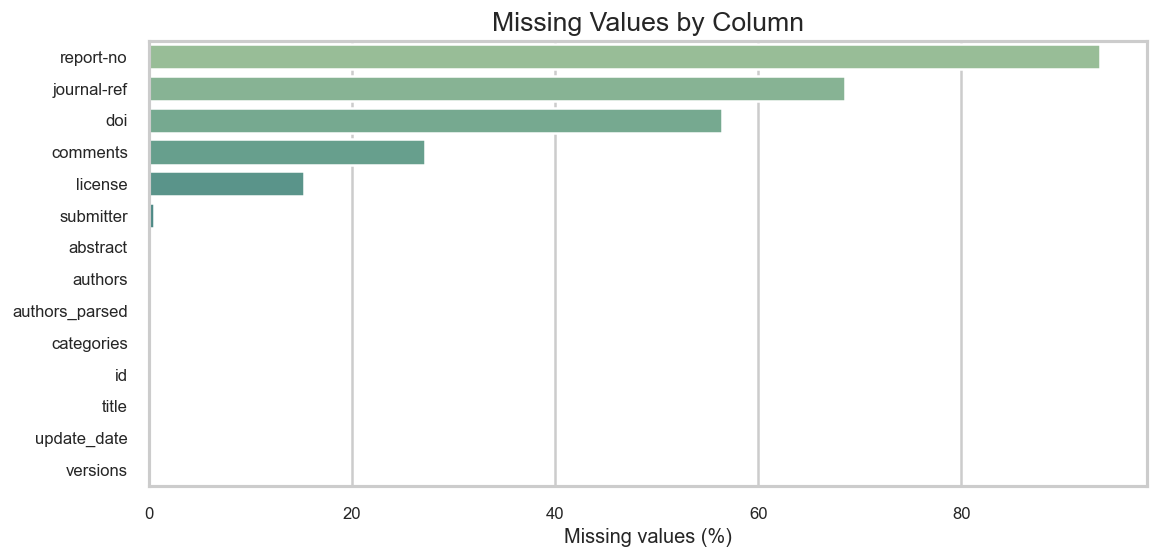

,Check,Count,Why it matters
0,Duplicate paper IDs,26,Exact identifier collisions that should be removed before splitting.
1,Exact duplicate title records,4367,Repeated titles can artificially tighten clusters.
2,Near-duplicate titles (normalized),6190,Case/punctuation variants that can still duplicate content.
3,Duplicate title+abstract records,485,A stronger proxy for repeated content.
4,Invalid submission dates,0,Temporal analysis is reliable if this remains near zero.
5,Invalid update dates,0,Revision-lag analysis depends on this field.
6,Malformed category tokens,0,Formatting inconsistencies would complicate label parsing.
7,Very short abstracts (<= 10 words),2111,Often withdrawn or placeholder-style records.
8,Very long abstracts (>= 300 words),11272,Can dominate token-based baselines and increase embedding cost.
9,Very short titles (<= 3 words),52158,Often too ambiguous to be used alone.


,duplicate_count,paper_id,title,categories
0,12,1104.4171,Discussion of: A statistical analysis of multiple temperature proxies: Are reconstructions of surface temperatures over the last 1000 years reliable?,stat.AP
1,11,1005.1676,Beyond the Standard Model,hep-ph
2,9,0905.1301,Rare Kaon Decays,hep-ex
3,9,0901.2505,Neutrino Physics,hep-ph
4,9,0807.4841,Physics Beyond the Standard Model,hep-ph hep-th


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_plot = column_overview.sort_values("missing_pct", ascending=False)
sns.barplot(data=missing_plot, x="missing_pct", y="column", hue="column", palette="crest", legend=False, ax=ax)
ax.set_title("Missing Values by Column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

quality_summary = pd.DataFrame(
    [
        ("Duplicate paper IDs", summary["duplicate_paper_ids"], "Exact identifier collisions that should be removed before splitting."),
        ("Exact duplicate title records", summary["duplicate_summary"]["exact_title"]["duplicate_records"], "Repeated titles can artificially tighten clusters."),
        ("Near-duplicate titles (normalized)", summary["duplicate_summary"]["normalized_title"]["duplicate_records"], "Case/punctuation variants that can still duplicate content."),
        ("Duplicate title+abstract records", summary["duplicate_summary"]["title_abstract_content"]["duplicate_records"], "A stronger proxy for repeated content."),
        ("Invalid submission dates", summary["invalid_submission_dates"], "Temporal analysis is reliable if this remains near zero."),
        ("Invalid update dates", summary["invalid_update_dates"], "Revision-lag analysis depends on this field."),
        ("Malformed category tokens", int(malformed_category_tokens["count"].sum()) if not malformed_category_tokens.empty else 0, "Formatting inconsistencies would complicate label parsing."),
        ("Very short abstracts (<= 10 words)", int((abstract_word_len <= 10).sum()), "Often withdrawn or placeholder-style records."),
        ("Very long abstracts (>= 300 words)", int((abstract_word_len >= 300).sum()), "Can dominate token-based baselines and increase embedding cost."),
        ("Very short titles (<= 3 words)", int((title_word_len <= 3).sum()), "Often too ambiguous to be used alone."),
    ],
    columns=["Check", "Count", "Why it matters"],
)

display(quality_summary)

duplicate_title_example_rows = []
exact_top = summary["duplicate_summary"]["exact_title"]["top_hashes"][:5]
for item in exact_top:
    example = duplicate_examples["exact_title"].get(str(item["hash"]), {})
    duplicate_title_example_rows.append(
        {
            "duplicate_count": item["count"],
            "paper_id": example.get("id", ""),
            "title": example.get("title", ""),
            "categories": example.get("categories", ""),
        }
    )

display(pd.DataFrame(duplicate_title_example_rows))

In [8]:
core_text_ok = (
    column_overview.loc[column_overview["column"].isin(["title", "abstract", "categories", "update_date"]), "missing_count"].sum() == 0
)

display(
    Markdown(
        f'''
**Interpretation.** Core analytical fields are in strong shape: missingness is concentrated in optional bibliographic metadata such as `journal-ref`, `doi`, and `report-no`, not in the text or category fields used for the benchmark. The main quality risks are therefore **duplicate or near-duplicate content** and **pathologically short abstracts**, not missing text.

The duplicate checks found **{summary['duplicate_paper_ids']} duplicate paper IDs**, **{summary['duplicate_summary']['exact_title']['duplicate_records']:,} exact duplicate-title records**, and **{summary['duplicate_summary']['title_abstract_content']['duplicate_records']:,} duplicate title-plus-abstract records**. These should be removed or consolidated before final experiments to avoid inflated cluster purity and overly optimistic retrieval behavior.
'''
    )
)


**Interpretation.** Core analytical fields are in strong shape: missingness is concentrated in optional bibliographic metadata such as `journal-ref`, `doi`, and `report-no`, not in the text or category fields used for the benchmark. The main quality risks are therefore **duplicate or near-duplicate content** and **pathologically short abstracts**, not missing text.

The duplicate checks found **26 duplicate paper IDs**, **4,367 exact duplicate-title records**, and **485 duplicate title-plus-abstract records**. These should be removed or consolidated before final experiments to avoid inflated cluster purity and overly optimistic retrieval behavior.


## 6. Category and Domain Analysis

Category imbalance matters directly for the benchmark because arXiv labels will be used as an external reference for cluster evaluation. We therefore inspect both the fine-grained primary categories and their coarser domain groupings.

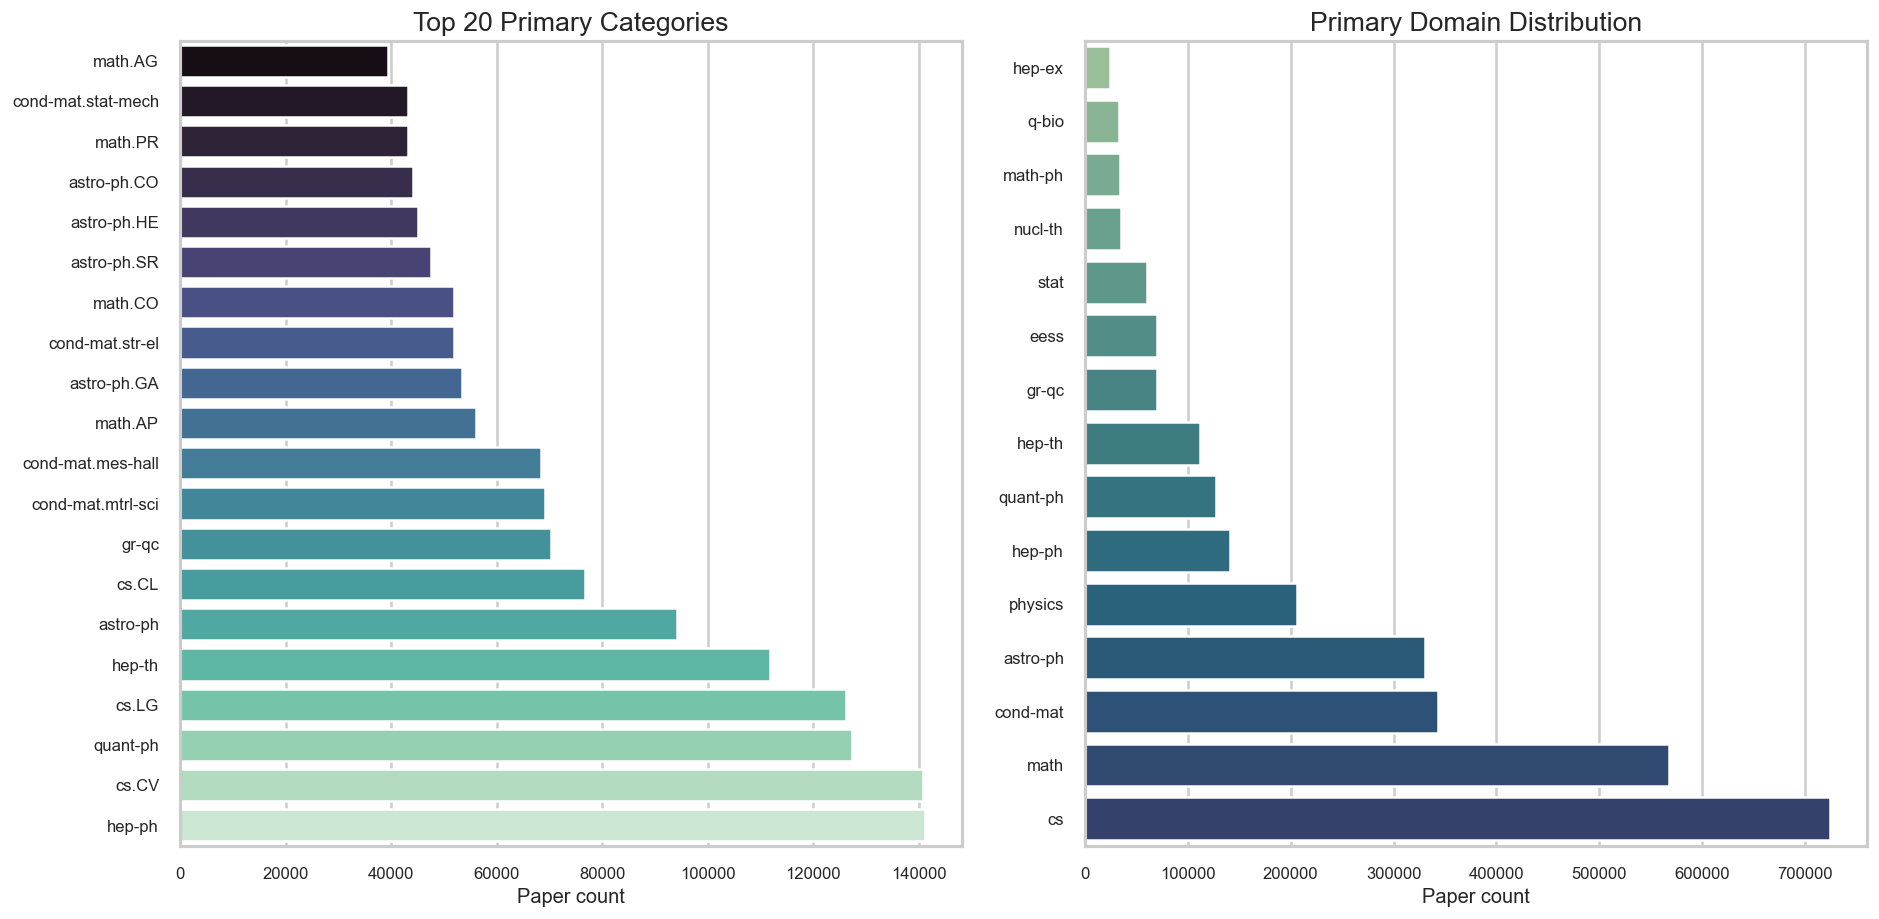

,primary_category,count,share_pct
0,hep-ph,141160,4.764
1,cs.CV,140840,4.753
2,quant-ph,127380,4.299
3,cs.LG,126126,4.256
4,hep-th,111849,3.775
5,astro-ph,94246,3.181
6,cs.CL,76834,2.593
7,gr-qc,70319,2.373
8,cond-mat.mtrl-sci,69201,2.335
9,cond-mat.mes-hall,68417,2.309


In [9]:
top20_primary = primary_category_counts.head(20).sort_values("count", ascending=True)
top15_domains = primary_domain_counts.head(15).sort_values("count", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(data=top20_primary, x="count", y="primary_category", hue="primary_category", palette="mako", legend=False, ax=axes[0])
axes[0].set_title("Top 20 Primary Categories")
axes[0].set_xlabel("Paper count")
axes[0].set_ylabel("")

sns.barplot(data=top15_domains, x="count", y="primary_domain", hue="primary_domain", palette="crest", legend=False, ax=axes[1])
axes[1].set_title("Primary Domain Distribution")
axes[1].set_xlabel("Paper count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(primary_category_counts.head(20))

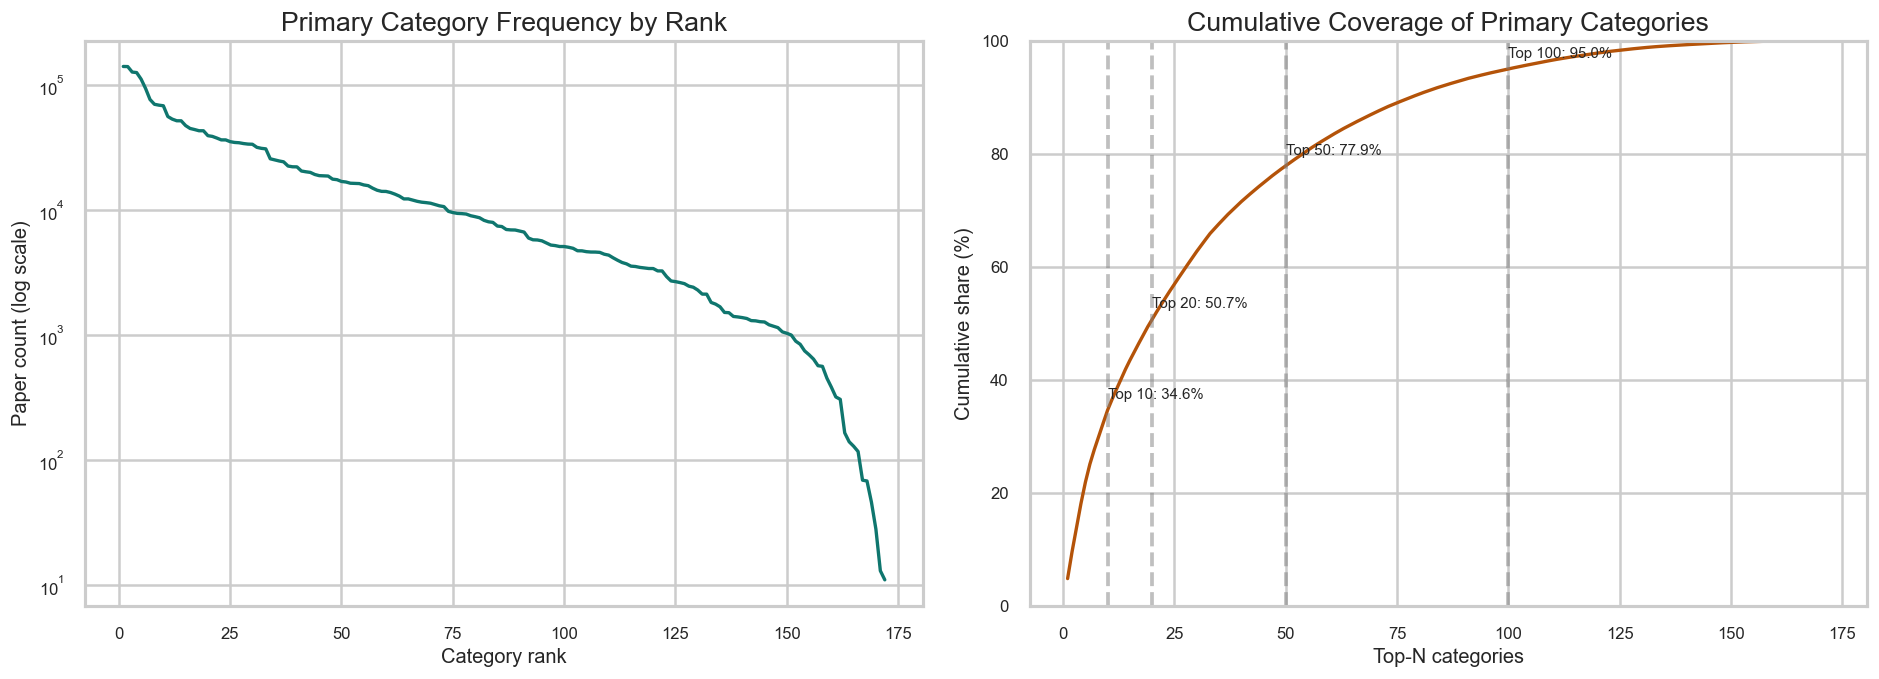

In [10]:
rank_df = primary_category_counts.copy()
rank_df["rank"] = np.arange(1, len(rank_df) + 1)
rank_df["cumulative_share_pct"] = rank_df["count"].cumsum() / rank_df["count"].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(rank_df["rank"], rank_df["count"], color="#0f766e", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_title("Primary Category Frequency by Rank")
axes[0].set_xlabel("Category rank")
axes[0].set_ylabel("Paper count (log scale)")

axes[1].plot(rank_df["rank"], rank_df["cumulative_share_pct"], color="#b45309", linewidth=2)
for cutoff in [10, 20, 50, 100]:
    share = rank_df.loc[rank_df["rank"] <= cutoff, "count"].sum() / rank_df["count"].sum() * 100
    axes[1].axvline(cutoff, color="gray", linestyle="--", alpha=0.5)
    axes[1].text(cutoff, min(share + 2, 98), f"Top {cutoff}: {share:.1f}%", fontsize=9, ha="left")
axes[1].set_ylim(0, 100)
axes[1].set_title("Cumulative Coverage of Primary Categories")
axes[1].set_xlabel("Top-N categories")
axes[1].set_ylabel("Cumulative share (%)")

plt.tight_layout()
plt.show()

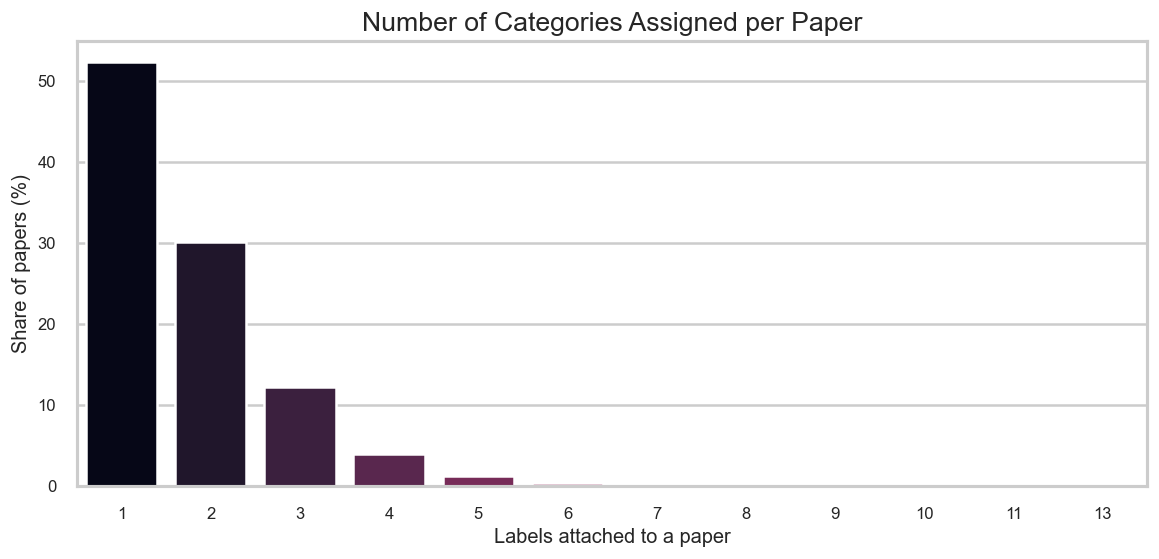

,label_count,count,share_pct
0,1,1549587,52.295
1,2,892645,30.125
2,3,361803,12.210
3,4,116810,3.942
4,5,33699,1.137
5,6,7359,0.248
6,7,1037,0.035
7,8,172,0.006
8,9,34,0.001
9,10,14,0.000


,category_combination,count,share_pct
0,cs.IT | math.IT,24751,0.835
1,cs.LG | cs.AI,17384,0.587
2,cs.LG | stat.ML,16441,0.555
3,math.NA | cs.NA,15431,0.521
4,cs.CL | cs.AI,14065,0.475
5,hep-ph | hep-ex,14050,0.474
6,math-ph | math.MP,13236,0.447
7,eess.SY | cs.SY,13221,0.446
8,cs.CV | cs.AI,12464,0.421
9,hep-th | gr-qc,12257,0.414


Categories that appear only as secondary labels: ['math.IT', 'math.MP', 'q-bio', 'stat.TH']


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=label_count_distribution, x="label_count", y="share_pct", hue="label_count", palette="rocket", legend=False, ax=ax)
ax.set_title("Number of Categories Assigned per Paper")
ax.set_xlabel("Labels attached to a paper")
ax.set_ylabel("Share of papers (%)")
plt.tight_layout()
plt.show()

only_secondary_categories = sorted(set(all_category_counts["category"]) - set(primary_category_counts["primary_category"]))

display(label_count_distribution)
display(category_combinations.head(15))
print("Categories that appear only as secondary labels:", only_secondary_categories)

In [12]:
top10_share = primary_category_counts.head(10)["count"].sum() / primary_category_counts["count"].sum() * 100
top20_share = primary_category_counts.head(20)["count"].sum() / primary_category_counts["count"].sum() * 100
top50_share = primary_category_counts.head(50)["count"].sum() / primary_category_counts["count"].sum() * 100

display(
    Markdown(
        f'''
**Interpretation.** The label space is both **broad** and **imbalanced**. There are **{summary['unique_primary_categories']} primary categories** for evaluation, while the broader multi-label vocabulary spans **{summary['unique_all_categories']} labels**. The top primary category covers only **{summary['top_primary_category_share_pct']:.2f}%** of the corpus, but concentration accumulates quickly: the **top 10 primary categories already cover {top10_share:.1f}%** of papers, and the **top 50 cover {top50_share:.1f}%**.

Multi-label structure is not a corner case. Roughly **{summary['multi_label_share_pct']:.1f}%** of papers have more than one category, which means a single-label evaluation view will sometimes understate cross-disciplinary structure. For splitting and evaluation, the most defensible default is to stratify on the **primary category** while keeping the full multi-label assignments for error analysis and interpretation.
'''
    )
)


**Interpretation.** The label space is both **broad** and **imbalanced**. There are **172 primary categories** for evaluation, while the broader multi-label vocabulary spans **176 labels**. The top primary category covers only **4.76%** of the corpus, but concentration accumulates quickly: the **top 10 primary categories already cover 34.6%** of papers, and the **top 50 cover 77.9%**.

Multi-label structure is not a corner case. Roughly **47.7%** of papers have more than one category, which means a single-label evaluation view will sometimes understate cross-disciplinary structure. For splitting and evaluation, the most defensible default is to stratify on the **primary category** while keeping the full multi-label assignments for error analysis and interpretation.


## 7. Text Field Analysis

Embedding quality depends heavily on how scientific text behaves in practice. Here we examine title and abstract lengths, inspect text artifacts, and look at representative examples of normal, short, long, and problematic abstracts.

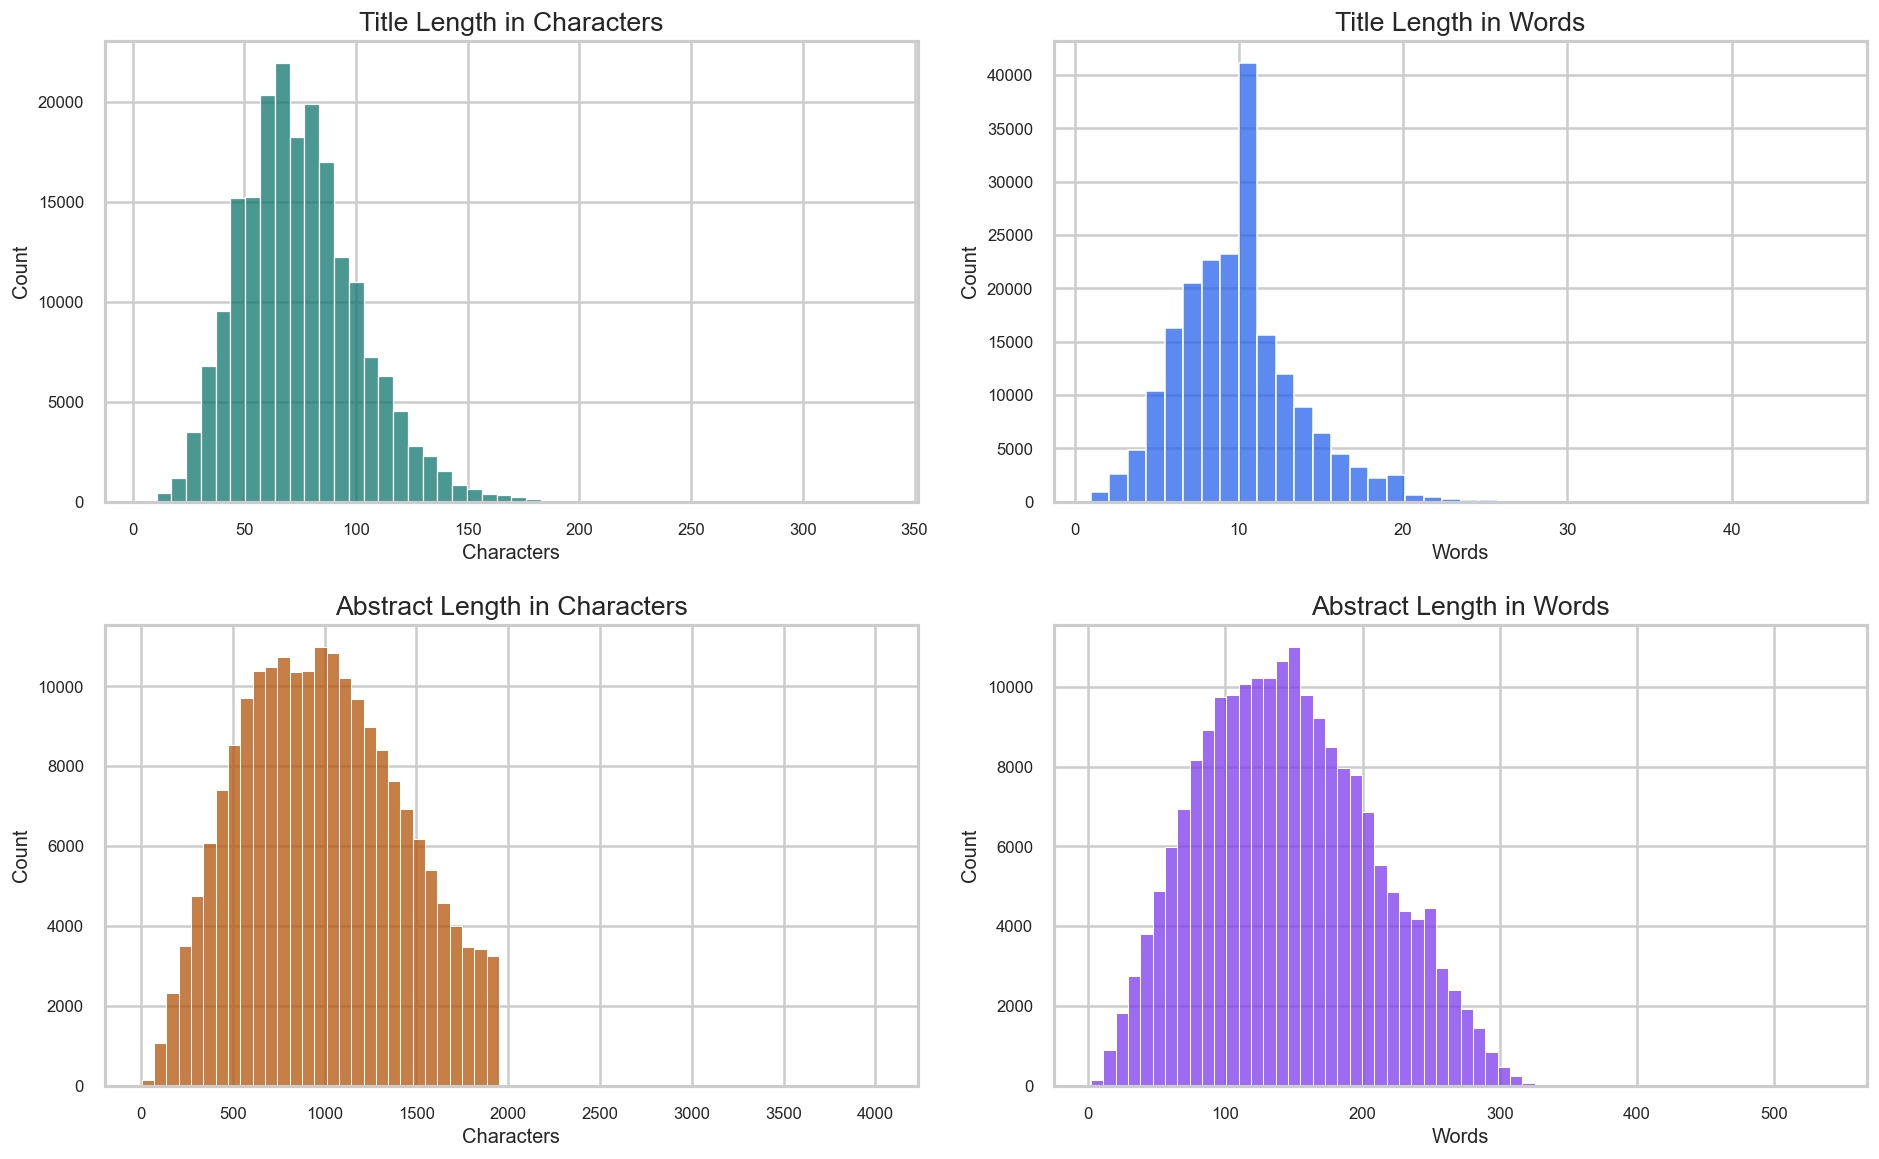

,percentile,title_char_len,title_word_len,abstract_char_len,abstract_word_len
0,0,1.000,1.000,3.000,1.000
1,25,56.000,7.000,652.000,97.000
2,50,72.000,9.000,968.000,141.000
3,75,91.000,12.000,"1,304.000",189.000
4,90,110.000,15.000,"1,600.000",234.000
5,95,122.000,16.000,"1,754.000",255.000
6,99,149.000,21.000,"1,903.000",288.000
7,100,372.000,61.000,"6,088.000",925.000


In [13]:
length_percentile_table = pd.DataFrame(
    {
        "title_char_len": summary["length_percentiles"]["title_char_len"],
        "title_word_len": summary["length_percentiles"]["title_word_len"],
        "abstract_char_len": summary["length_percentiles"]["abstract_char_len"],
        "abstract_word_len": summary["length_percentiles"]["abstract_word_len"],
    }
).rename_axis("percentile").reset_index()

rng = np.random.default_rng(RANDOM_SEED)
plot_size = min(200_000, len(abstract_word_len))
abstract_word_plot = rng.choice(abstract_word_len, size=plot_size, replace=False)
abstract_char_plot = rng.choice(abstract_char_len, size=plot_size, replace=False)
title_word_plot = rng.choice(title_word_len, size=plot_size, replace=False)
title_char_plot = rng.choice(title_char_len, size=plot_size, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(title_char_plot, bins=50, ax=axes[0, 0], color="#0f766e")
axes[0, 0].set_title("Title Length in Characters")
axes[0, 0].set_xlabel("Characters")

sns.histplot(title_word_plot, bins=40, ax=axes[0, 1], color="#2563eb")
axes[0, 1].set_title("Title Length in Words")
axes[0, 1].set_xlabel("Words")

sns.histplot(abstract_char_plot, bins=60, ax=axes[1, 0], color="#b45309")
axes[1, 0].set_title("Abstract Length in Characters")
axes[1, 0].set_xlabel("Characters")

sns.histplot(abstract_word_plot, bins=60, ax=axes[1, 1], color="#7c3aed")
axes[1, 1].set_title("Abstract Length in Words")
axes[1, 1].set_xlabel("Words")

plt.tight_layout()
plt.show()

display(length_percentile_table)

In [14]:
HTML_RE = re.compile(r"<[^>]+>")
LATEX_RE = re.compile(r"\\[A-Za-z]+|\$[^$]+\$|\\\(|\\\)|\\\[|\\\]|\\begin\{|\\end\{")
URL_RE = re.compile(r"https?://|www\.")
EMAIL_RE = re.compile(r"\b[\w.%-]+@[\w.-]+\.[A-Za-z]{2,}\b")
EXCESS_PUNCT_RE = re.compile(r"[!?.,;:]{4,}")
WITHDRAWN_RE = re.compile(r"withdrawn|retracted", re.I)
NON_ASCII_RE = re.compile(r"[^\x00-\x7F]")


def pattern_share(series: pd.Series, pattern: re.Pattern) -> float:
    return float(series.fillna("").str.contains(pattern, regex=True, na=False).mean() * 100)


pattern_summary = pd.DataFrame(
    [
        ("Title", "LaTeX-like markup", pattern_share(text_sample_df["title"], LATEX_RE)),
        ("Title", "URL", pattern_share(text_sample_df["title"], URL_RE)),
        ("Title", "Non-ASCII character", pattern_share(text_sample_df["title"], NON_ASCII_RE)),
        ("Abstract", "HTML-like tag", pattern_share(text_sample_df["abstract"], HTML_RE)),
        ("Abstract", "LaTeX-like markup", pattern_share(text_sample_df["abstract"], LATEX_RE)),
        ("Abstract", "URL", pattern_share(text_sample_df["abstract"], URL_RE)),
        ("Abstract", "Email address", pattern_share(text_sample_df["abstract"], EMAIL_RE)),
        ("Abstract", "Excess punctuation", pattern_share(text_sample_df["abstract"], EXCESS_PUNCT_RE)),
        ("Abstract", "Withdrawn / retracted wording", pattern_share(text_sample_df["abstract"], WITHDRAWN_RE)),
    ],
    columns=["Field", "Pattern", "Share of sample (%)"],
)


def make_example_table(frame: pd.DataFrame, rows: int = 3) -> pd.DataFrame:
    subset = frame.head(rows).copy()
    subset["abstract_preview"] = subset["abstract"].map(lambda x: clip_text(x, 220))
    return subset[["id", "title", "abstract_word_len", "abstract_preview"]]


normal_examples = text_sample_df[
    (text_sample_df["abstract_word_len"].between(110, 180))
    & (~text_sample_df["abstract"].str.contains(LATEX_RE, regex=True, na=False))
    & (~text_sample_df["abstract"].str.contains(URL_RE, regex=True, na=False))
    & (~text_sample_df["abstract"].str.contains(WITHDRAWN_RE, regex=True, na=False))
].head(3)

problematic_examples = text_sample_df[
    text_sample_df["abstract"].str.contains(LATEX_RE, regex=True, na=False)
    | text_sample_df["abstract"].str.contains(URL_RE, regex=True, na=False)
    | text_sample_df["abstract"].str.contains(WITHDRAWN_RE, regex=True, na=False)
    | text_sample_df["abstract"].str.contains(HTML_RE, regex=True, na=False)
].head(3)

short_examples = text_sample_df.nsmallest(3, "abstract_word_len")
long_examples = text_sample_df.nlargest(3, "abstract_word_len")

display(pattern_summary)
display(make_example_table(normal_examples))
display(make_example_table(problematic_examples))
display(make_example_table(short_examples))
display(make_example_table(long_examples))

,Field,Pattern,Share of sample (%)
0,Title,LaTeX-like markup,5.942
1,Title,URL,0.000
2,Title,Non-ASCII character,0.000
3,Abstract,HTML-like tag,0.995
4,Abstract,LaTeX-like markup,32.250
5,Abstract,URL,2.575
6,Abstract,Email address,0.005
7,Abstract,Excess punctuation,0.320
8,Abstract,Withdrawn / retracted wording,0.070


,id,title,abstract_word_len,abstract_preview
1,2010.04736,Evaluating and Characterizing Human Rationales,117,Two main approaches for evaluating the quality of machine-generated rationales are: 1) using human rationales as a gold standard; and 2) automated metrics based on how rational...
3,2306.05431,LexGPT 0.1: pre-trained GPT-J models with Pile of Law,155,This research aims to build generative language models specialized for the legal domain. The manuscript presents the development of LexGPT models based on GPT-J models and pre-...
8,2601.06748,On-the-Fly VLA Adaptation via Test-Time Reinforcement Learning,158,"Vision-Language-Action models have recently emerged as a powerful paradigm for general-purpose robot learning, enabling agents to map visual observations and natural-language i..."


,id,title,abstract_word_len,abstract_preview
0,1509.08575,On uncrossing games for skew-supermodular functions,86,"In this note, we consider the uncrossing game for a skew-supermodular function $f$, which is a two-player game with players, Red and Blue, and abstracts the uncrossing procedur..."
2,hep-th/9202033,The Canonical Structure of Wess-Zumino-Witten Models,56,"The phase space of the Wess-Zumino-Witten model on a circle with target space a compact, connected, semisimple Lie group $G$ is defined and the corresponding symplectic form is..."
6,1712.02261,Disorder and critical phenomena: the $\alpha=0$ copolymer model,183,The generalized copolymer model is a disordered system built on a discrete renewal process with inter-arrival distribution that decays in a regularly varying fashion with expon...


,id,title,abstract_word_len,abstract_preview
31742,1102.1124,A Polynomial Time Algorithm for a Special Case of Linear Integer Programming,5,This article has been withdrawn.
35110,hep-ph/9912257,Mass hierarchies and mixing angles,5,The paper has been withdrawn
2976,astro-ph/9905072,The Dyadosphere of Black Holes and Gamma-Ray Bursts,7,Recent works on the Dyadosphere are reviewed.


,id,title,abstract_word_len,abstract_preview
14585,1003.2052,The evolutionary status of the blue hook stars in Omega Centauri,381,"Core helium burning is the dominant source of energy of extreme horizontal branch stars, as the hydrogen envelope is too small to contribute to the nuclear energy output. The e..."
24585,1910.03438,Fast Diameter Computation within Split Graphs,380,"When can we compute the diameter of a graph in quasi linear time? We address this question for the class of {\em split graphs}, that we observe to be the hardest instances for ..."
14456,1804.09407,The use of a pruned modular decomposition for Maximum Matching algorithms on some graph classes,372,"We address the following general question: given a graph class C on which we can solve Maximum Matching in (quasi) linear time, does the same hold true for the class of graphs ..."


In [15]:
display(
    Markdown(
        f'''
**Interpretation.** Abstract lengths are reasonably well behaved for embedding models: the median abstract is **{summary['length_percentiles']['abstract_word_len']['50']:.0f} words**, and even the 95th percentile is only **{summary['length_percentiles']['abstract_word_len']['95']:.0f} words**. That is short enough for standard transformer input windows when title and abstract are concatenated.

The more meaningful text-quality issue is **scientific markup**, not raw length. In the reservoir sample, LaTeX-like patterns appear in a substantial fraction of abstracts, and URLs or withdrawn notices are present but much rarer. This argues for **light artifact handling** rather than aggressive normalization: scientific symbols carry signal, but withdrawn placeholders and duplicated notices should not remain in the modeling corpus unchanged.
'''
    )
)


**Interpretation.** Abstract lengths are reasonably well behaved for embedding models: the median abstract is **141 words**, and even the 95th percentile is only **255 words**. That is short enough for standard transformer input windows when title and abstract are concatenated.

The more meaningful text-quality issue is **scientific markup**, not raw length. In the reservoir sample, LaTeX-like patterns appear in a substantial fraction of abstracts, and URLs or withdrawn notices are present but much rarer. This argues for **light artifact handling** rather than aggressive normalization: scientific symbols carry signal, but withdrawn placeholders and duplicated notices should not remain in the modeling corpus unchanged.


## 8. Preprocessing-Oriented Analysis

The purpose of preprocessing EDA is not to blindly clean the corpus as much as possible. Instead, it is to quantify what different normalization choices do to the vocabulary and token distribution so later modeling choices are evidence-based.

For transformer-style scientific embeddings such as SciBERT or SPECTER, aggressive stopword removal, stemming, and formula stripping can remove useful scientific cues. For traditional bag-of-words baselines, however, lowercasing and punctuation cleanup are still reasonable. The comparisons below are therefore intentionally lightweight.

,Configuration,vocab_size,total_tokens,hapax_vocab_pct,stopword_token_pct,numeric_token_pct,punct_token_pct,top100_token_share_pct,vocab_reduction_vs_raw_pct
0,Raw lowercase tokenization,105625,3152206,49.614,39.301,2.021,7.812,41.347,0.000
1,Lowercase + punctuation removal,56736,3264169,37.095,38.660,2.321,0.000,41.935,46.285
2,Lowercase + punctuation removal + stopword removal,56438,2002232,37.282,0.000,3.784,0.000,18.453,46.568


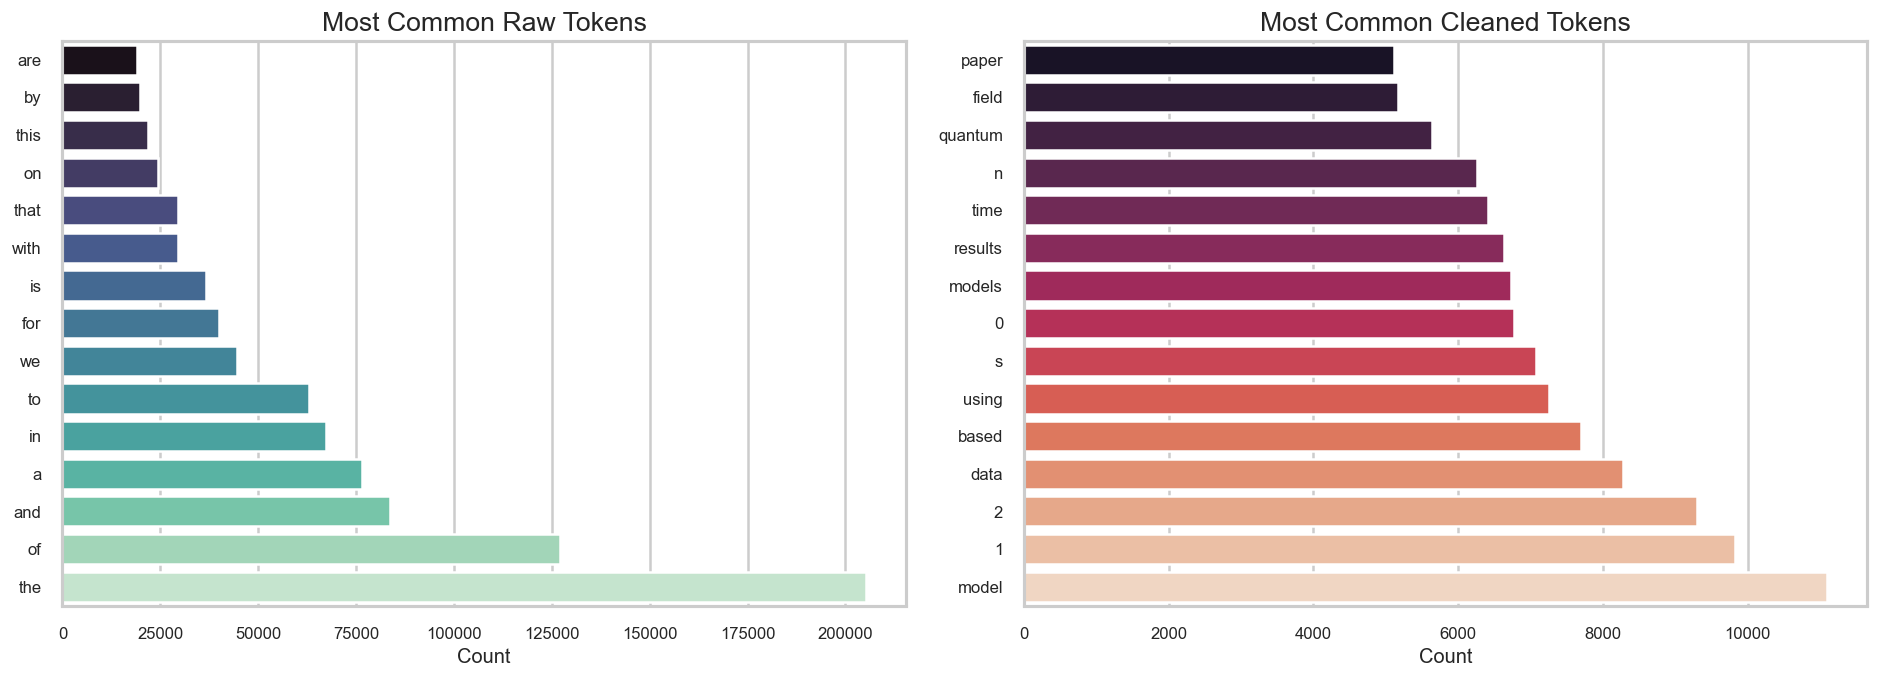

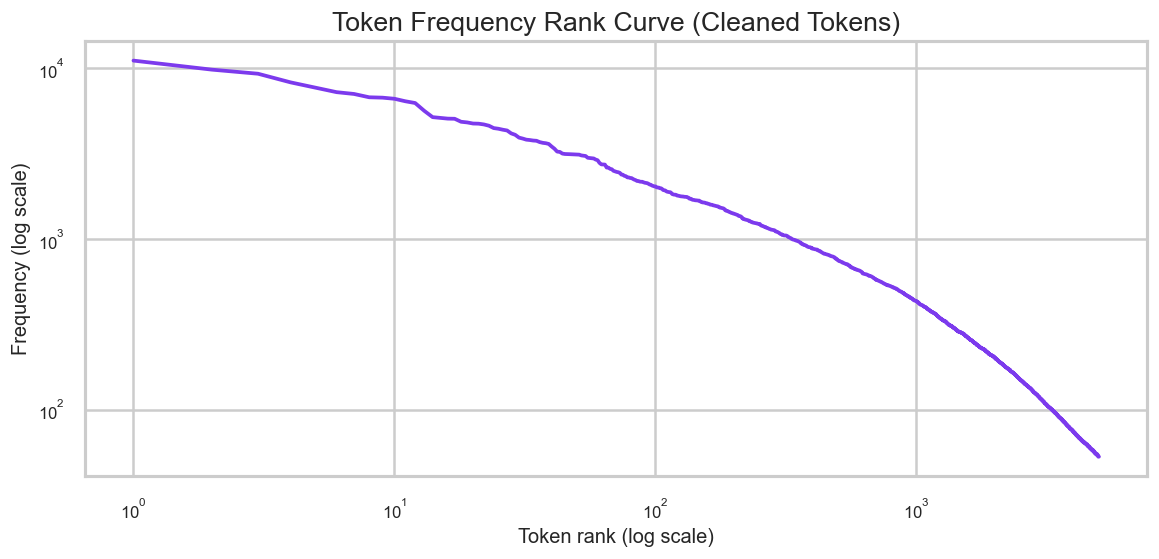

In [16]:
stopwords = set(ENGLISH_STOP_WORDS)
analysis_texts = (text_sample_df["title"].fillna("") + " " + text_sample_df["abstract"].fillna("")).tolist()[:TEXT_ANALYSIS_SAMPLE]


def tokenize_raw_lower(text: str) -> list[str]:
    return [token.lower() for token in TOKEN_RE.findall(text)]


def tokenize_no_punct(text: str) -> list[str]:
    lowered = NON_ALNUM_SPACE_RE.sub(" ", text.lower())
    return [token for token in WS_RE.split(lowered) if token]


def tokenize_no_punct_stop(text: str) -> list[str]:
    return [token for token in tokenize_no_punct(text) if token not in stopwords]


def token_profile(texts: list[str], tokenizer) -> tuple[Counter, dict]:
    counter = Counter()
    total_tokens = 0
    stop_tokens = 0
    numeric_tokens = 0
    punct_tokens = 0

    for text in texts:
        tokens = tokenizer(text)
        counter.update(tokens)
        total_tokens += len(tokens)
        stop_tokens += sum(token in stopwords for token in tokens)
        numeric_tokens += sum(any(ch.isdigit() for ch in token) for token in tokens)
        punct_tokens += sum(bool(re.search(r"[^\w\s]", token)) for token in tokens)

    vocab_size = len(counter)
    hapax = sum(1 for value in counter.values() if value == 1)
    top100_share = sum(value for _, value in counter.most_common(100)) / total_tokens * 100 if total_tokens else 0.0

    metrics = {
        "vocab_size": vocab_size,
        "total_tokens": total_tokens,
        "hapax_vocab_pct": hapax / vocab_size * 100 if vocab_size else 0.0,
        "stopword_token_pct": stop_tokens / total_tokens * 100 if total_tokens else 0.0,
        "numeric_token_pct": numeric_tokens / total_tokens * 100 if total_tokens else 0.0,
        "punct_token_pct": punct_tokens / total_tokens * 100 if total_tokens else 0.0,
        "top100_token_share_pct": top100_share,
    }
    return counter, metrics


tokenizers = {
    "Raw lowercase tokenization": tokenize_raw_lower,
    "Lowercase + punctuation removal": tokenize_no_punct,
    "Lowercase + punctuation removal + stopword removal": tokenize_no_punct_stop,
}

token_counters = {}
token_metrics_rows = []
for config_name, tokenizer in tokenizers.items():
    counter, metrics = token_profile(analysis_texts, tokenizer)
    token_counters[config_name] = counter
    token_metrics_rows.append({"Configuration": config_name, **metrics})

token_metrics_df = pd.DataFrame(token_metrics_rows)
token_metrics_df["vocab_reduction_vs_raw_pct"] = (
    1 - token_metrics_df["vocab_size"] / token_metrics_df.loc[0, "vocab_size"]
) * 100

display(token_metrics_df)

raw_top = pd.DataFrame(token_counters["Raw lowercase tokenization"].most_common(15), columns=["token", "count"])
clean_top = pd.DataFrame(
    token_counters["Lowercase + punctuation removal + stopword removal"].most_common(15),
    columns=["token", "count"],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=raw_top.sort_values("count"), x="count", y="token", hue="token", palette="mako", legend=False, ax=axes[0])
axes[0].set_title("Most Common Raw Tokens")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.barplot(data=clean_top.sort_values("count"), x="count", y="token", hue="token", palette="rocket", legend=False, ax=axes[1])
axes[1].set_title("Most Common Cleaned Tokens")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

cleaned_freq = np.array(sorted(token_counters["Lowercase + punctuation removal + stopword removal"].values(), reverse=True))
ranks = np.arange(1, min(len(cleaned_freq), 5000) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ranks, cleaned_freq[: len(ranks)], color="#7c3aed")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Token Frequency Rank Curve (Cleaned Tokens)")
ax.set_xlabel("Token rank (log scale)")
ax.set_ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()

In [17]:
raw_vocab = token_metrics_df.loc[token_metrics_df["Configuration"] == "Raw lowercase tokenization", "vocab_size"].iloc[0]
clean_vocab = token_metrics_df.loc[
    token_metrics_df["Configuration"] == "Lowercase + punctuation removal + stopword removal",
    "vocab_size",
].iloc[0]

display(
    Markdown(
        f'''
**Interpretation.** The vocabulary contracts sharply under light preprocessing: in the sampled corpus, moving from raw lowercase tokenization to punctuation removal plus stopword removal reduces the observed vocabulary from **{raw_vocab:,}** to **{clean_vocab:,}** unique tokens. At the same time, raw scientific text still contains meaningful structure such as symbols, short alphanumeric identifiers, and formula tokens.

**Implication for modeling.**
- For **transformer embeddings** (for example, SciBERT-like or SPECTER-like encoders), prefer **minimal normalization**: whitespace cleanup, optional URL/email stripping, and removal of obviously withdrawn placeholders. Avoid stemming, lemmatization, and blanket stopword removal.
- For **TF-IDF or bag-of-words baselines**, `lowercase + punctuation removal + stopword removal` is a sensible default, ideally paired with `min_df` filtering to suppress the long tail of ultra-rare tokens.
'''
    )
)


**Interpretation.** The vocabulary contracts sharply under light preprocessing: in the sampled corpus, moving from raw lowercase tokenization to punctuation removal plus stopword removal reduces the observed vocabulary from **105,625** to **56,438** unique tokens. At the same time, raw scientific text still contains meaningful structure such as symbols, short alphanumeric identifiers, and formula tokens.

**Implication for modeling.**
- For **transformer embeddings** (for example, SciBERT-like or SPECTER-like encoders), prefer **minimal normalization**: whitespace cleanup, optional URL/email stripping, and removal of obviously withdrawn placeholders. Avoid stemming, lemmatization, and blanket stopword removal.
- For **TF-IDF or bag-of-words baselines**, `lowercase + punctuation removal + stopword removal` is a sensible default, ideally paired with `min_df` filtering to suppress the long tail of ultra-rare tokens.


## 9. Temporal and Metadata Analysis

Temporal skew affects both benchmarking and retrieval. A corpus dominated by recent submissions from fast-growing domains can bias cluster composition, nearest-neighbor retrieval, and any downstream qualitative interpretation of discovered topics.

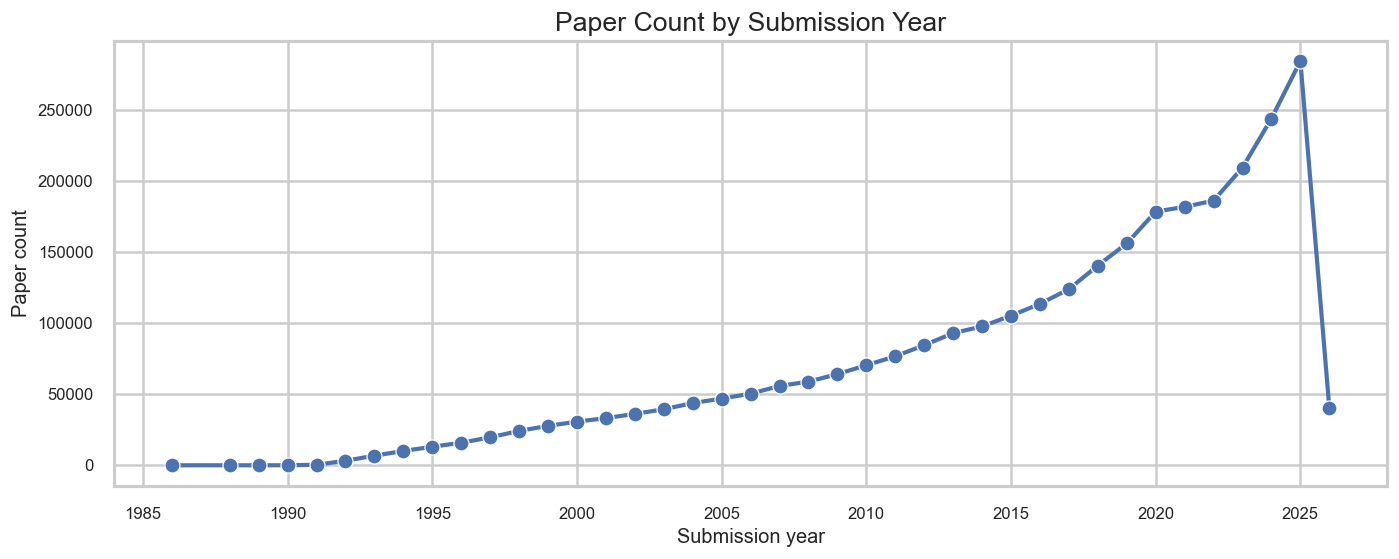

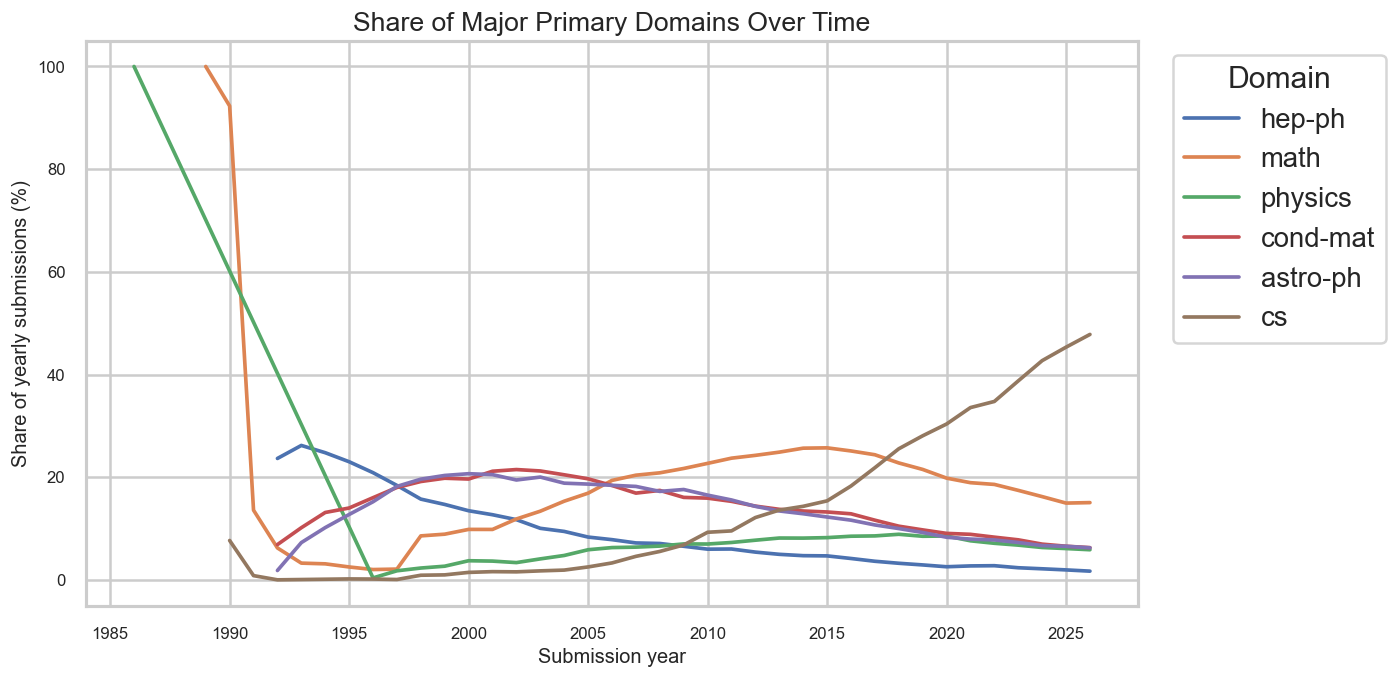

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=submission_year_counts, x="submission_year", y="count", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Paper Count by Submission Year")
ax.set_xlabel("Submission year")
ax.set_ylabel("Paper count")
plt.tight_layout()
plt.show()

top_domains = primary_domain_counts.head(6)["primary_domain"].tolist()
domain_year = primary_domain_year_counts[primary_domain_year_counts["primary_domain"].isin(top_domains)].copy()
year_totals = primary_domain_year_counts.groupby("submission_year")["count"].sum().rename("year_total")
domain_year = domain_year.merge(year_totals, on="submission_year", how="left")
domain_year["share_pct"] = domain_year["count"] / domain_year["year_total"] * 100

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=domain_year,
    x="submission_year",
    y="share_pct",
    hue="primary_domain",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Share of Major Primary Domains Over Time")
ax.set_xlabel("Submission year")
ax.set_ylabel("Share of yearly submissions (%)")
ax.legend(title="Domain", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

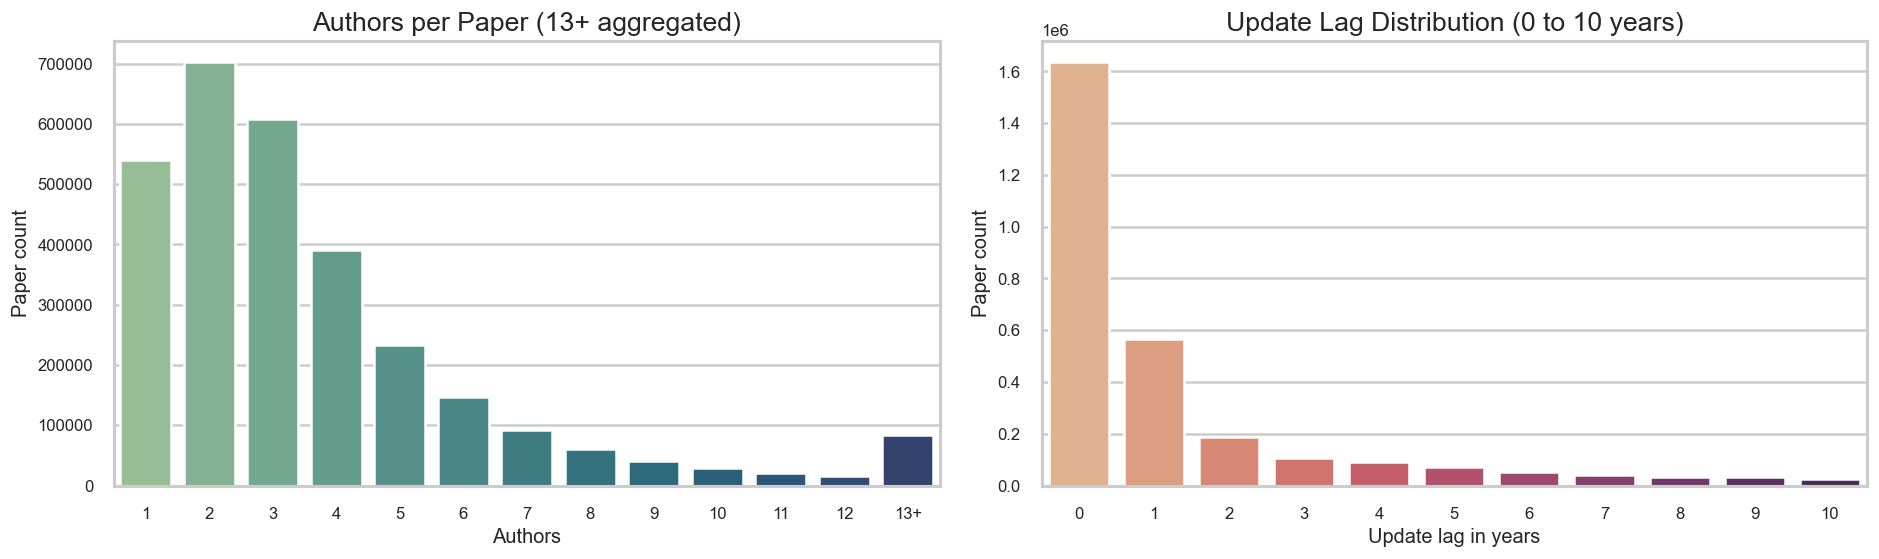

In [19]:
author_plot = author_count_distribution.copy()
author_plot["author_bucket"] = author_plot["author_count"].where(author_plot["author_count"] <= 12, 13)
author_bucket = (
    author_plot.groupby("author_bucket", as_index=False)["count"].sum().assign(
        label=lambda df: df["author_bucket"].astype(str).replace({"13": "13+"})
    )
)

lag_plot = update_lag_distribution[update_lag_distribution["update_lag_years"] <= 10].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=author_bucket, x="label", y="count", hue="label", palette="crest", legend=False, ax=axes[0])
axes[0].set_title("Authors per Paper (13+ aggregated)")
axes[0].set_xlabel("Authors")
axes[0].set_ylabel("Paper count")

sns.barplot(data=lag_plot, x="update_lag_years", y="count", hue="update_lag_years", palette="flare", legend=False, ax=axes[1])
axes[1].set_title("Update Lag Distribution (0 to 10 years)")
axes[1].set_xlabel("Update lag in years")
axes[1].set_ylabel("Paper count")

plt.tight_layout()
plt.show()

In [20]:
cs_2010 = (
    domain_year[(domain_year["primary_domain"] == "cs") & (domain_year["submission_year"] == 2010)]["share_pct"].iloc[0]
)
cs_2025 = (
    domain_year[(domain_year["primary_domain"] == "cs") & (domain_year["submission_year"] == 2025)]["share_pct"].iloc[0]
)
recent_share = submission_year_counts.loc[submission_year_counts["submission_year"] >= 2018, "count"].sum() / submission_year_counts["count"].sum() * 100

display(
    Markdown(
        f'''
**Interpretation.** The corpus is strongly **temporally skewed toward recent years**: about **{recent_share:.1f}%** of all papers were submitted in **2018 or later**. The domain mix has also shifted substantially. In the primary-domain view, **computer science grew from {cs_2010:.1f}% of yearly submissions in 2010 to {cs_2025:.1f}% in 2025**.

This matters for evaluation and retrieval. A random sample from the full corpus will naturally be dominated by recent, CS-heavy material unless time is explicitly controlled. If the benchmark claims broad scientific coverage, this temporal shift should be stated clearly in the report.
'''
    )
)


**Interpretation.** The corpus is strongly **temporally skewed toward recent years**: about **54.7%** of all papers were submitted in **2018 or later**. The domain mix has also shifted substantially. In the primary-domain view, **computer science grew from 9.3% of yearly submissions in 2010 to 45.3% in 2025**.

This matters for evaluation and retrieval. A random sample from the full corpus will naturally be dominated by recent, CS-heavy material unless time is explicitly controlled. If the benchmark claims broad scientific coverage, this temporal shift should be stated clearly in the report.


## 10. Data Splitting Strategy Analysis

The benchmark needs a split strategy that preserves label proportions without overcomplicating a multi-label setting. Since arXiv records can have several categories, we evaluate the practical compromise of stratifying on the primary category while retaining the full multi-label information for analysis.

,minimum_sample_count_per_class,eligible_sample_rows,eligible_sample_classes,stratified_70_10_20_works_on_sample
0,2,199997,169,False
1,3,199993,167,False
2,5,199989,166,False
3,10,199968,163,True
4,20,199935,161,True


,strategy,split,size,mean_abs_diff_pct_points,max_abs_diff_pct_points,missing_categories
0,Random,Train,139977,0.008,0.052,0
1,Random,Validation,19997,0.033,0.206,0
2,Random,Test,39994,0.025,0.140,0
3,Stratified,Train,139977,0.000,0.000,0
4,Stratified,Validation,19997,0.001,0.004,0
5,Stratified,Test,39994,0.001,0.002,0


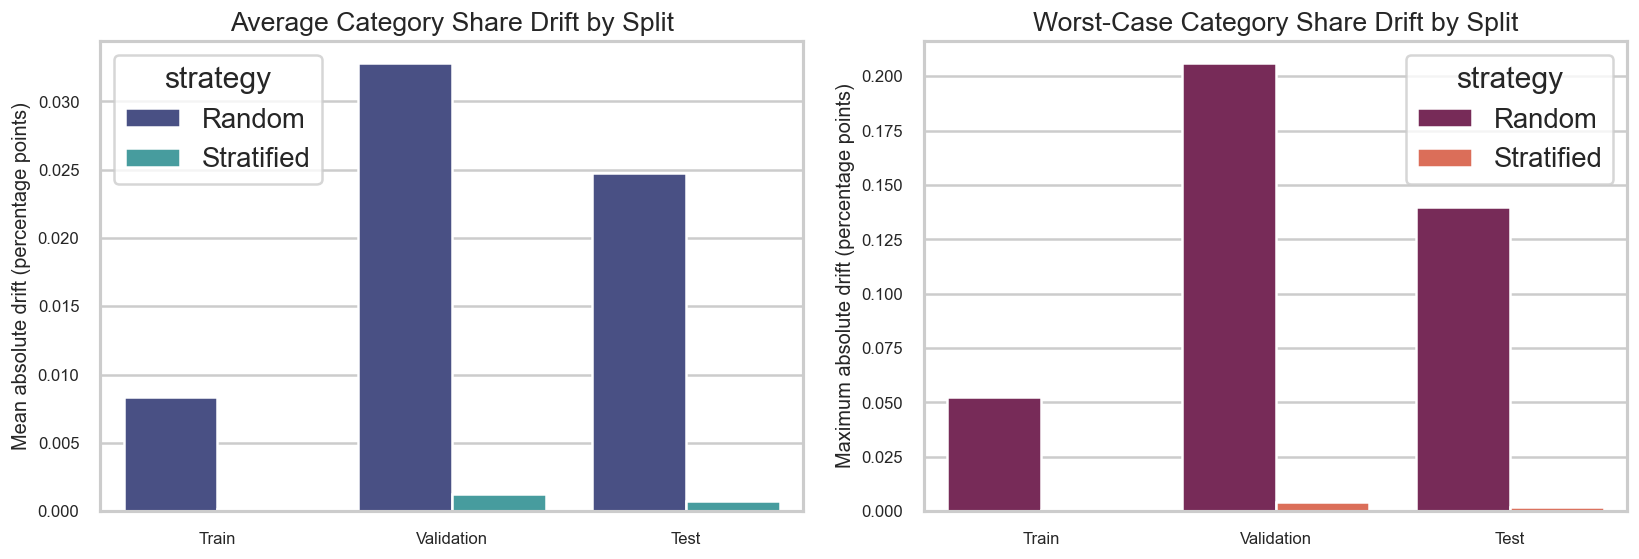

,primary_category,global,split,abs_diff_pct_points
0,cs.CL,0.026,0.025,0.140
1,cond-mat.soft,0.010,0.012,0.121
2,hep-th,0.038,0.037,0.105
3,cond-mat.mtrl-sci,0.023,0.022,0.100
4,math.PR,0.015,0.014,0.095
5,physics.flu-dyn,0.008,0.007,0.089
6,nucl-th,0.012,0.013,0.081
7,cs.IT,0.013,0.012,0.079
8,astro-ph.CO,0.015,0.016,0.078
9,stat.ML,0.007,0.006,0.071


,primary_category,global,split,abs_diff_pct_points
0,hep-th,0.038,0.038,0.002
1,cs.LG,0.043,0.043,0.002
2,quant-ph,0.043,0.043,0.002
3,math.AG,0.013,0.013,0.002
4,math.OC,0.013,0.013,0.002
5,math.NA,0.011,0.011,0.002
6,cs.SE,0.007,0.007,0.002
7,cs.DS,0.006,0.006,0.002
8,nucl-ex,0.004,0.004,0.002
9,cs.SI,0.004,0.004,0.002


In [21]:
def evaluate_thresholds(split_df: pd.DataFrame, thresholds=(2, 3, 5, 10, 20), random_state: int = RANDOM_SEED) -> pd.DataFrame:
    rows = []
    label_counts = split_df["primary_category"].value_counts()
    for threshold in thresholds:
        eligible = split_df[split_df["primary_category"].map(label_counts) >= threshold].copy()
        works = True
        try:
            train_tmp, heldout_tmp = train_test_split(
                eligible,
                test_size=0.30,
                random_state=random_state,
                stratify=eligible["primary_category"],
            )
            train_test_split(
                heldout_tmp,
                test_size=2 / 3,
                random_state=random_state,
                stratify=heldout_tmp["primary_category"],
            )
        except Exception:
            works = False

        rows.append(
            {
                "minimum_sample_count_per_class": threshold,
                "eligible_sample_rows": len(eligible),
                "eligible_sample_classes": eligible["primary_category"].nunique(),
                "stratified_70_10_20_works_on_sample": works,
            }
        )
    return pd.DataFrame(rows)


def simulate_split_strategies(
    split_df: pd.DataFrame,
    minimum_count: int = SPLIT_SIMULATION_MIN_COUNT,
    random_state: int = RANDOM_SEED,
):
    label_counts = split_df["primary_category"].value_counts()
    eligible = split_df[split_df["primary_category"].map(label_counts) >= minimum_count].copy()

    train_random, temp_random = train_test_split(eligible, test_size=0.30, random_state=random_state)
    val_random, test_random = train_test_split(temp_random, test_size=2 / 3, random_state=random_state)

    train_strat, temp_strat = train_test_split(
        eligible,
        test_size=0.30,
        random_state=random_state,
        stratify=eligible["primary_category"],
    )
    val_strat, test_strat = train_test_split(
        temp_strat,
        test_size=2 / 3,
        random_state=random_state,
        stratify=temp_strat["primary_category"],
    )

    global_dist = eligible["primary_category"].value_counts(normalize=True)

    def summarize(name, frames):
        rows = []
        drift_tables = {}
        for split_name, frame in frames.items():
            dist = frame["primary_category"].value_counts(normalize=True)
            aligned = global_dist.to_frame("global").join(dist.to_frame("split"), how="left").fillna(0)
            aligned["abs_diff_pct_points"] = (aligned["split"] - aligned["global"]).abs() * 100
            rows.append(
                {
                    "strategy": name,
                    "split": split_name,
                    "size": len(frame),
                    "mean_abs_diff_pct_points": aligned["abs_diff_pct_points"].mean(),
                    "max_abs_diff_pct_points": aligned["abs_diff_pct_points"].max(),
                    "missing_categories": int((aligned["split"] == 0).sum()),
                }
            )
            drift_tables[(name, split_name)] = aligned.sort_values("abs_diff_pct_points", ascending=False)
        return rows, drift_tables

    random_rows, random_tables = summarize(
        "Random",
        {"Train": train_random, "Validation": val_random, "Test": test_random},
    )
    strat_rows, strat_tables = summarize(
        "Stratified",
        {"Train": train_strat, "Validation": val_strat, "Test": test_strat},
    )

    summary_frame = pd.DataFrame(random_rows + strat_rows)
    return eligible, summary_frame, {**random_tables, **strat_tables}


threshold_table = evaluate_thresholds(split_sample_df)
eligible_split_sample, split_strategy_summary, drift_tables = simulate_split_strategies(split_sample_df)

display(threshold_table)
display(split_strategy_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=split_strategy_summary,
    x="split",
    y="mean_abs_diff_pct_points",
    hue="strategy",
    palette="mako",
    ax=axes[0],
)
axes[0].set_title("Average Category Share Drift by Split")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean absolute drift (percentage points)")

sns.barplot(
    data=split_strategy_summary,
    x="split",
    y="max_abs_diff_pct_points",
    hue="strategy",
    palette="rocket",
    ax=axes[1],
)
axes[1].set_title("Worst-Case Category Share Drift by Split")
axes[1].set_xlabel("")
axes[1].set_ylabel("Maximum absolute drift (percentage points)")

plt.tight_layout()
plt.show()

worst_random_test = drift_tables[("Random", "Test")].head(10).reset_index().rename(columns={"index": "primary_category"})
worst_strat_test = drift_tables[("Stratified", "Test")].head(10).reset_index().rename(columns={"index": "primary_category"})

display(worst_random_test[["primary_category", "global", "split", "abs_diff_pct_points"]])
display(worst_strat_test[["primary_category", "global", "split", "abs_diff_pct_points"]])

In [22]:
full_min_primary = int(primary_category_counts["count"].min())
rare_primary_le_50 = int((primary_category_counts["count"] <= 50).sum())

display(
    Markdown(
        f'''
**Interpretation.** On the full dataset, the smallest primary category still has **{full_min_primary} papers**, so a **70/10/20 split stratified by primary category is feasible** across all 172 primary labels. In the sample-based simulation, stratification dramatically reduces distribution drift relative to naive random splitting.

**Recommendation.**
- Use **70/10/20 stratified sampling on `primary_category`** as the default split strategy.
- Keep the **full multi-label category string** for analysis, but do not require exact multi-label stratification for the first benchmark iteration.
- Mention that **{rare_primary_le_50} primary categories have 50 papers or fewer**, so validation and test statistics for those rare classes will still be noisy even under stratification.
'''
    )
)


**Interpretation.** On the full dataset, the smallest primary category still has **11 papers**, so a **70/10/20 split stratified by primary category is feasible** across all 172 primary labels. In the sample-based simulation, stratification dramatically reduces distribution drift relative to naive random splitting.

**Recommendation.**
- Use **70/10/20 stratified sampling on `primary_category`** as the default split strategy.
- Keep the **full multi-label category string** for analysis, but do not require exact multi-label stratification for the first benchmark iteration.
- Mention that **4 primary categories have 50 papers or fewer**, so validation and test statistics for those rare classes will still be noisy even under stratification.


## 11. Outliers, Edge Cases, and Risks

The goal of this section is to convert the EDA into modeling guidance. Each row below links an empirical observation to a concrete risk for clustering, embedding generation, evaluation, or retrieval design.

In [23]:
recent_share = submission_year_counts.loc[submission_year_counts["submission_year"] >= 2018, "count"].sum() / submission_year_counts["count"].sum() * 100
top50_share = primary_category_counts.head(50)["count"].sum() / primary_category_counts["count"].sum() * 100

risk_register = pd.DataFrame(
    [
        (
            "Long-tail label imbalance",
            f"Top 50 primary categories account for {top50_share:.1f}% of papers; 4 primary categories have 50 papers or fewer.",
            "K-means centroids will be pulled toward dominant categories; macro evaluation across rare categories will be unstable.",
            "Report both aggregate and sensitivity analyses, and interpret rare-category metrics cautiously.",
        ),
        (
            "Multi-label ambiguity",
            f"{summary['multi_label_share_pct']:.1f}% of papers carry multiple categories.",
            "A single reference label can penalize clusters that capture cross-disciplinary structure.",
            "Use primary labels for the main split/evaluation, but analyze multi-label cases separately in the report.",
        ),
        (
            "Duplicate and near-duplicate content",
            f"{summary['duplicate_paper_ids']} duplicate IDs, {summary['duplicate_summary']['normalized_title']['duplicate_records']:,} normalized-title duplicates, and {summary['duplicate_summary']['title_abstract_content']['duplicate_records']:,} duplicate title+abstract records.",
            "Duplicates can inflate cluster purity and retrieval precision by injecting repeated content.",
            "Deduplicate on paper ID and normalized title+abstract before final benchmarking.",
        ),
        (
            "Short or placeholder abstracts",
            f"{int((abstract_word_len <= 10).sum()):,} abstracts have 10 words or fewer; sample inspection shows withdrawn placeholders.",
            "These documents are poor inputs for semantic embeddings and can form degenerate clusters.",
            "Filter withdrawn or ultra-short records, or route them to a separate error bucket.",
        ),
        (
            "Scientific markup and artifact text",
            "Sample-based inspection shows frequent LaTeX and smaller amounts of URLs / HTML-like text.",
            "Aggressive cleanup can remove scientific meaning, while no cleanup can hurt token baselines.",
            "Use minimal cleanup for transformer encoders and stronger normalization only for TF-IDF-style baselines.",
        ),
        (
            "Temporal skew",
            f"{recent_share:.1f}% of papers were submitted in 2018 or later, with strong recent growth in CS-related domains.",
            "Recent, CS-heavy topics can dominate both clustering and nearest-neighbor retrieval if time is ignored.",
            "Document the skew and consider time-aware analyses or at least temporal breakdowns in the report.",
        ),
        (
            "Computational scale",
            f"The corpus contains {summary['record_count']:,} papers.",
            "Agglomerative clustering on all pairwise distances is infeasible; full-corpus embeddings also require batching and indexing.",
            "Prefer batched embedding generation, approximate nearest-neighbor retrieval, and scalable clustering variants such as MiniBatchKMeans or staged hierarchical approaches.",
        ),
    ],
    columns=["Risk", "Evidence", "Downstream impact", "Mitigation"],
)

display(risk_register)

,Risk,Evidence,Downstream impact,Mitigation
0,Long-tail label imbalance,Top 50 primary categories account for 77.9% of papers; 4 primary categories have 50 papers or fewer.,K-means centroids will be pulled toward dominant categories; macro evaluation across rare categories will be unstable.,"Report both aggregate and sensitivity analyses, and interpret rare-category metrics cautiously."
1,Multi-label ambiguity,47.7% of papers carry multiple categories.,A single reference label can penalize clusters that capture cross-disciplinary structure.,"Use primary labels for the main split/evaluation, but analyze multi-label cases separately in the report."
2,Duplicate and near-duplicate content,"26 duplicate IDs, 6,190 normalized-title duplicates, and 485 duplicate title+abstract records.",Duplicates can inflate cluster purity and retrieval precision by injecting repeated content.,Deduplicate on paper ID and normalized title+abstract before final benchmarking.
3,Short or placeholder abstracts,"2,111 abstracts have 10 words or fewer; sample inspection shows withdrawn placeholders.",These documents are poor inputs for semantic embeddings and can form degenerate clusters.,"Filter withdrawn or ultra-short records, or route them to a separate error bucket."
4,Scientific markup and artifact text,Sample-based inspection shows frequent LaTeX and smaller amounts of URLs / HTML-like text.,"Aggressive cleanup can remove scientific meaning, while no cleanup can hurt token baselines.",Use minimal cleanup for transformer encoders and stronger normalization only for TF-IDF-style baselines.
5,Temporal skew,"54.7% of papers were submitted in 2018 or later, with strong recent growth in CS-related domains.","Recent, CS-heavy topics can dominate both clustering and nearest-neighbor retrieval if time is ignored.",Document the skew and consider time-aware analyses or at least temporal breakdowns in the report.
6,Computational scale,"The corpus contains 2,963,163 papers.",Agglomerative clustering on all pairwise distances is infeasible; full-corpus embeddings also require batching and indexing.,"Prefer batched embedding generation, approximate nearest-neighbor retrieval, and scalable clustering variants such as MiniBatchKMeans or staged hierarchical approaches."


## 12. Key Findings and Recommendations

In [24]:
top_domain = primary_domain_counts.iloc[0]
final_note = f'''
### Key Findings

- The corpus is large and modeling-ready at the core-field level: **{summary['record_count']:,} papers**, **{summary['unique_primary_categories']} primary categories**, and complete coverage for `title`, `abstract`, `categories`, `versions`, and `update_date`.
- Category imbalance is real but not pathological at the head: the largest primary category covers **{summary['top_primary_category_share_pct']:.2f}%** of the corpus, while the primary-domain view is led by **{top_domain['primary_domain']} ({top_domain['share_pct']:.1f}%)**.
- Multi-label structure is common, not exceptional: **{summary['multi_label_share_pct']:.1f}%** of papers have multiple category assignments.
- Text lengths are manageable for modern encoders: the median abstract is **{summary['length_percentiles']['abstract_word_len']['50']:.0f} words**, and the 95th percentile is **{summary['length_percentiles']['abstract_word_len']['95']:.0f} words**.
- The main data-quality risks are **duplicates**, **withdrawn / placeholder abstracts**, and **scientific markup artifacts**, not missing core text.
- The dataset is temporally skewed toward recent years, with a visibly increasing computer-science share in the later part of the corpus.

### Recommended Preprocessing

- For **transformer embeddings**: keep title and abstract largely intact, apply whitespace normalization, optionally strip obvious URL/email noise, and filter withdrawn or ultra-short placeholder abstracts. Do **not** default to stemming or stopword removal.
- For **TF-IDF or bag-of-words baselines**: use lowercasing, punctuation removal, stopword removal, and a sensible `min_df` threshold to control the rare-token tail.
- Deduplicate on **paper ID** and preferably on a **normalized title-plus-abstract hash** before benchmarking.

### Recommended Experimental Design

- Use a **70/10/20 split stratified by primary category**.
- Use the **primary category** as the main external evaluation label, but keep full multi-label assignments for analysis and caveats.
- Report the full **172-category** benchmark, but consider an additional sensitivity analysis on a filtered subset or minimum-support threshold because the tail remains thin for a handful of categories.
- Treat scalability as a first-class benchmarking constraint: use batched embeddings, avoid naive full-corpus agglomerative clustering, and document runtime or memory tradeoffs alongside quality metrics.

### Report Caveats Worth Explicitly Mentioning

- arXiv categories are an imperfect proxy for latent topics, especially for multi-label and cross-disciplinary papers.
- Temporal and domain skew can bias both cluster composition and retrieval examples.
- Rare categories and duplicated content can distort evaluation if they are not handled explicitly.
'''

display(Markdown(final_note))


### Key Findings

- The corpus is large and modeling-ready at the core-field level: **2,963,163 papers**, **172 primary categories**, and complete coverage for `title`, `abstract`, `categories`, `versions`, and `update_date`.
- Category imbalance is real but not pathological at the head: the largest primary category covers **4.76%** of the corpus, while the primary-domain view is led by **cs (24.4%)**.
- Multi-label structure is common, not exceptional: **47.7%** of papers have multiple category assignments.
- Text lengths are manageable for modern encoders: the median abstract is **141 words**, and the 95th percentile is **255 words**.
- The main data-quality risks are **duplicates**, **withdrawn / placeholder abstracts**, and **scientific markup artifacts**, not missing core text.
- The dataset is temporally skewed toward recent years, with a visibly increasing computer-science share in the later part of the corpus.

### Recommended Preprocessing

- For **transformer embeddings**: keep title and abstract largely intact, apply whitespace normalization, optionally strip obvious URL/email noise, and filter withdrawn or ultra-short placeholder abstracts. Do **not** default to stemming or stopword removal.
- For **TF-IDF or bag-of-words baselines**: use lowercasing, punctuation removal, stopword removal, and a sensible `min_df` threshold to control the rare-token tail.
- Deduplicate on **paper ID** and preferably on a **normalized title-plus-abstract hash** before benchmarking.

### Recommended Experimental Design

- Use a **70/10/20 split stratified by primary category**.
- Use the **primary category** as the main external evaluation label, but keep full multi-label assignments for analysis and caveats.
- Report the full **172-category** benchmark, but consider an additional sensitivity analysis on a filtered subset or minimum-support threshold because the tail remains thin for a handful of categories.
- Treat scalability as a first-class benchmarking constraint: use batched embeddings, avoid naive full-corpus agglomerative clustering, and document runtime or memory tradeoffs alongside quality metrics.

### Report Caveats Worth Explicitly Mentioning

- arXiv categories are an imperfect proxy for latent topics, especially for multi-label and cross-disciplinary papers.
- Temporal and domain skew can bias both cluster composition and retrieval examples.
- Rare categories and duplicated content can distort evaluation if they are not handled explicitly.
